<a href="https://colab.research.google.com/github/fariha34/CSE-427/blob/main/GroupProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***CSE427 Project: Network Intrusion Detection (CICIDS2017)***

Goal: Multiclass attack detection

Introduction:

Everyday the number of network users is increasing, so does the network attacks.So the need for network traffic analysis and reliable intrusion detection is also increasing.Our dataset is an ideal IDS (Intrusion Detection System) dataset for intrusion detection as it has rich attack diversity and metadata with almost 80 network flow features.

The dataset is huge with 79 columns. It has a high class imbalance.

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score


from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')


**Loading Dataset**

In [ ]:
# Install dependencies
# pip install kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "combinenew.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "naeem41/cicids2017-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())


Using Colab cache for faster access to the 'cicids2017-dataset' dataset.
First 5 records:    Destination Port   Flow Duration   Total Fwd Packets  \
0             54865             3.0                 2.0   
1             55054           109.0                 1.0   
2             55055            52.0                 1.0   
3             46236            34.0                 1.0   
4             54863             3.0                 2.0   

    Total Backward Packets  Total Length of Fwd Packets  \
0                      0.0                         12.0   
1                      1.0                          6.0   
2                      1.0                          6.0   
3                      1.0                          6.0   
4                      0.0                         12.0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                           0.0                     6.0   
1                           6.0                     6.0   
2                      

## EDA

In [ ]:
df.shape

(2830744, 79)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830744 entries, 0 to 2830743
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             object 
 1    Flow Duration                float64
 2    Total Fwd Packets            float64
 3    Total Backward Packets       float64
 4   Total Length of Fwd Packets   float64
 5    Total Length of Bwd Packets  float64
 6    Fwd Packet Length Max        float64
 7    Fwd Packet Length Min        float64
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         float64
 11   Bwd Packet Length Min        float64
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [ ]:
df.nunique()

,0
Destination Port,54772
Flow Duration,1050899
Total Fwd Packets,1432
Total Backward Packets,1747
Total Length of Fwd Packets,17928
...,...
Idle Mean,221686
Idle Std,197145
Idle Max,149737
Idle Min,223888


In [ ]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,1
Total Fwd Packets,1
Total Backward Packets,1
Total Length of Fwd Packets,1
...,...
Idle Mean,1
Idle Std,1
Idle Max,1
Idle Min,1


In [ ]:
#checking the categorical and numerical data
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)


Categorical Variables:
[' Destination Port', ' Label']
Numerical Variables:
[' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Co

In [ ]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())


['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [ ]:
print(df['Label'].value_counts())


Label
BENIGN                      2273097
DoS Hulk                     231073
PortScan                     158930
DDoS                         128027
DoS GoldenEye                 10293
FTP-Patator                    7938
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1966
Web Attack_Brute Force         1507
Web Attack_XSS                  652
Infiltration                     36
Web Attack_Sql Injection         21
Heartbleed                       11
Name: count, dtype: int64


**Benign traffic is much more common than any type of attack. Some attack classes, such as Heartbleed, Infiltration, and Web Attack SQL Injection, have fewer than 40 samples each. Because of this imbalance, we will use resampling to balance the dataset.**

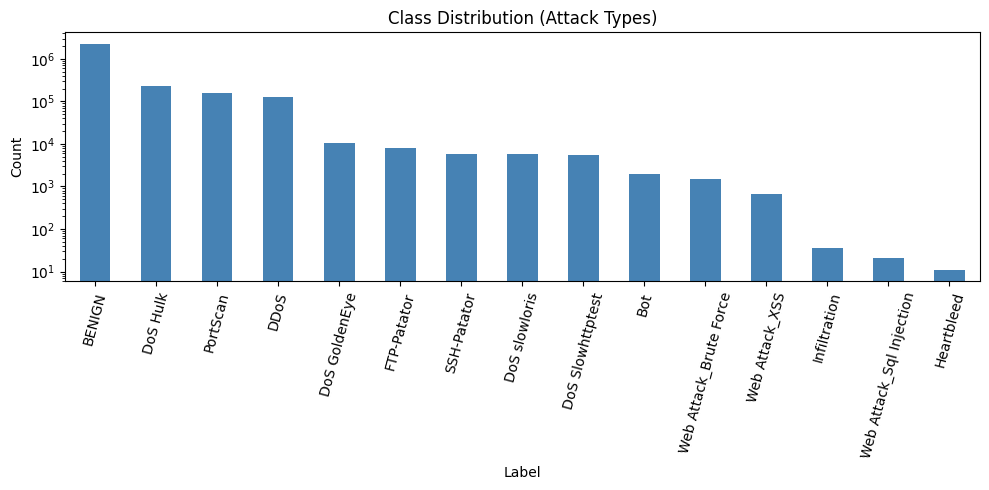

In [ ]:
plt.figure(figsize=(10, 5))
df['Label'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution (Attack Types)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.yscale('log')  # log scale, since BENIGN is too common
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


**Data Cleaning**

We will remove three types of unnecessary columns.:

ID-like columns (Flow ID, ports, and timestamps) as these may identify individual flows rather than helping the model learn general attack patterns.
Zero-variance columns as columns with the same value in every row provide no useful information for distinguishing classes.
Duplicate columns because if two columns contain exactly the same values, we will keep only one since the other does not add any new information.

In [ ]:
#Dropping redundant features

id_like_cols = ['Flow ID', 'Timestamp']
id_cols_found = [c for c in id_like_cols if c in df.columns]

num_cols = df.select_dtypes(include=np.number).columns.tolist()
zero_var_cols = [c for c in num_cols if df[c].nunique() <= 1]

duplicate_cols = []
seen = {}
for col in df.columns:
    col_hash = pd.util.hash_pandas_object(df[col]).sum()
    if col_hash in seen:
        duplicate_cols.append(col)
    else:
        seen[col_hash] = col

cols_to_drop = list(set(id_cols_found + zero_var_cols + duplicate_cols))
print("Dropping", len(cols_to_drop), "columns:", cols_to_drop)

df = df.drop(columns=cols_to_drop, errors='ignore')
print("Shape after dropping redundant columns:", df.shape)

Dropping 14 columns: ['Bwd URG Flags', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Bulk Rate', 'SYN Flag Count', 'Subflow Fwd Packets', 'Subflow Bwd Packets', 'Fwd Header Length.1', 'Bwd Avg Packets/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Avg Fwd Segment Size', 'Fwd Avg Bytes/Bulk', 'CWE Flag Count', 'Bwd PSH Flags']
Shape after dropping redundant columns: (2830744, 65)


In [ ]:
#Replacing infinite values with NaN, checking counts
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Missing values per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))


Missing values per column (top 10):
Flow Bytes/s                   2838
Flow Packets/s                 2834
Bwd Header Length                 1
Flow Duration                     1
Total Fwd Packets                 1
Total Length of Bwd Packets       1
Fwd Packet Length Max             1
Total Backward Packets            1
Total Length of Fwd Packets       1
Fwd Packet Length Mean            1
dtype: int64


In [ ]:
# Drop rows with any remaining NaNs
df.dropna(inplace=True)


In [ ]:
# Drop duplicates
df = df.drop_duplicates()
df


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830738,53,32215.0,4.0,2.0,112.0,152.0,28.0,28.0,28.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2830739,53,324.0,2.0,2.0,84.0,362.0,42.0,42.0,42.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2830740,58030,82.0,2.0,1.0,31.0,6.0,31.0,0.0,15.5,21.92031,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2830741,53,1048635.0,6.0,2.0,192.0,256.0,32.0,32.0,32.0,0.00000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [ ]:
print("Shape after cleaning:", df.shape)


Shape after cleaning: (2498796, 65)


In [ ]:
df.isnull().sum()

,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
...,...
Idle Mean,0
Idle Std,0
Idle Max,0
Idle Min,0


In [ ]:
#checking for categorical and numerical variables in df
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)


Categorical Variables:
['Destination Port', 'Label']
Numerical Variables:
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'ECE Flag Count', 'Down/Up Rati

In [ ]:
#correlation matrix on numeric features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numeric_cols].corr()

#highly correlated pairs (|r| > 0.9)
threshold = 0.9
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
print(f"Found {len(high_corr_df)} feature pairs with |correlation| > {threshold}")

# show the whole list, not just what pandas would normally truncate to
pd.set_option('display.max_rows', None)
display(high_corr_df)
pd.reset_option('display.max_rows')


Found 58 feature pairs with |correlation| > 0.9


,Feature 1,Feature 2,Correlation
6,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000
7,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000
19,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000
1,Total Fwd Packets,Total Backward Packets,0.999
0,Flow Duration,Fwd IAT Total,0.999
31,Flow IAT Max,Fwd IAT Max,0.998
47,Packet Length Mean,Average Packet Size,0.998
52,RST Flag Count,ECE Flag Count,0.998
3,Total Fwd Packets,Subflow Bwd Bytes,0.997
2,Total Fwd Packets,Total Length of Bwd Packets,0.997


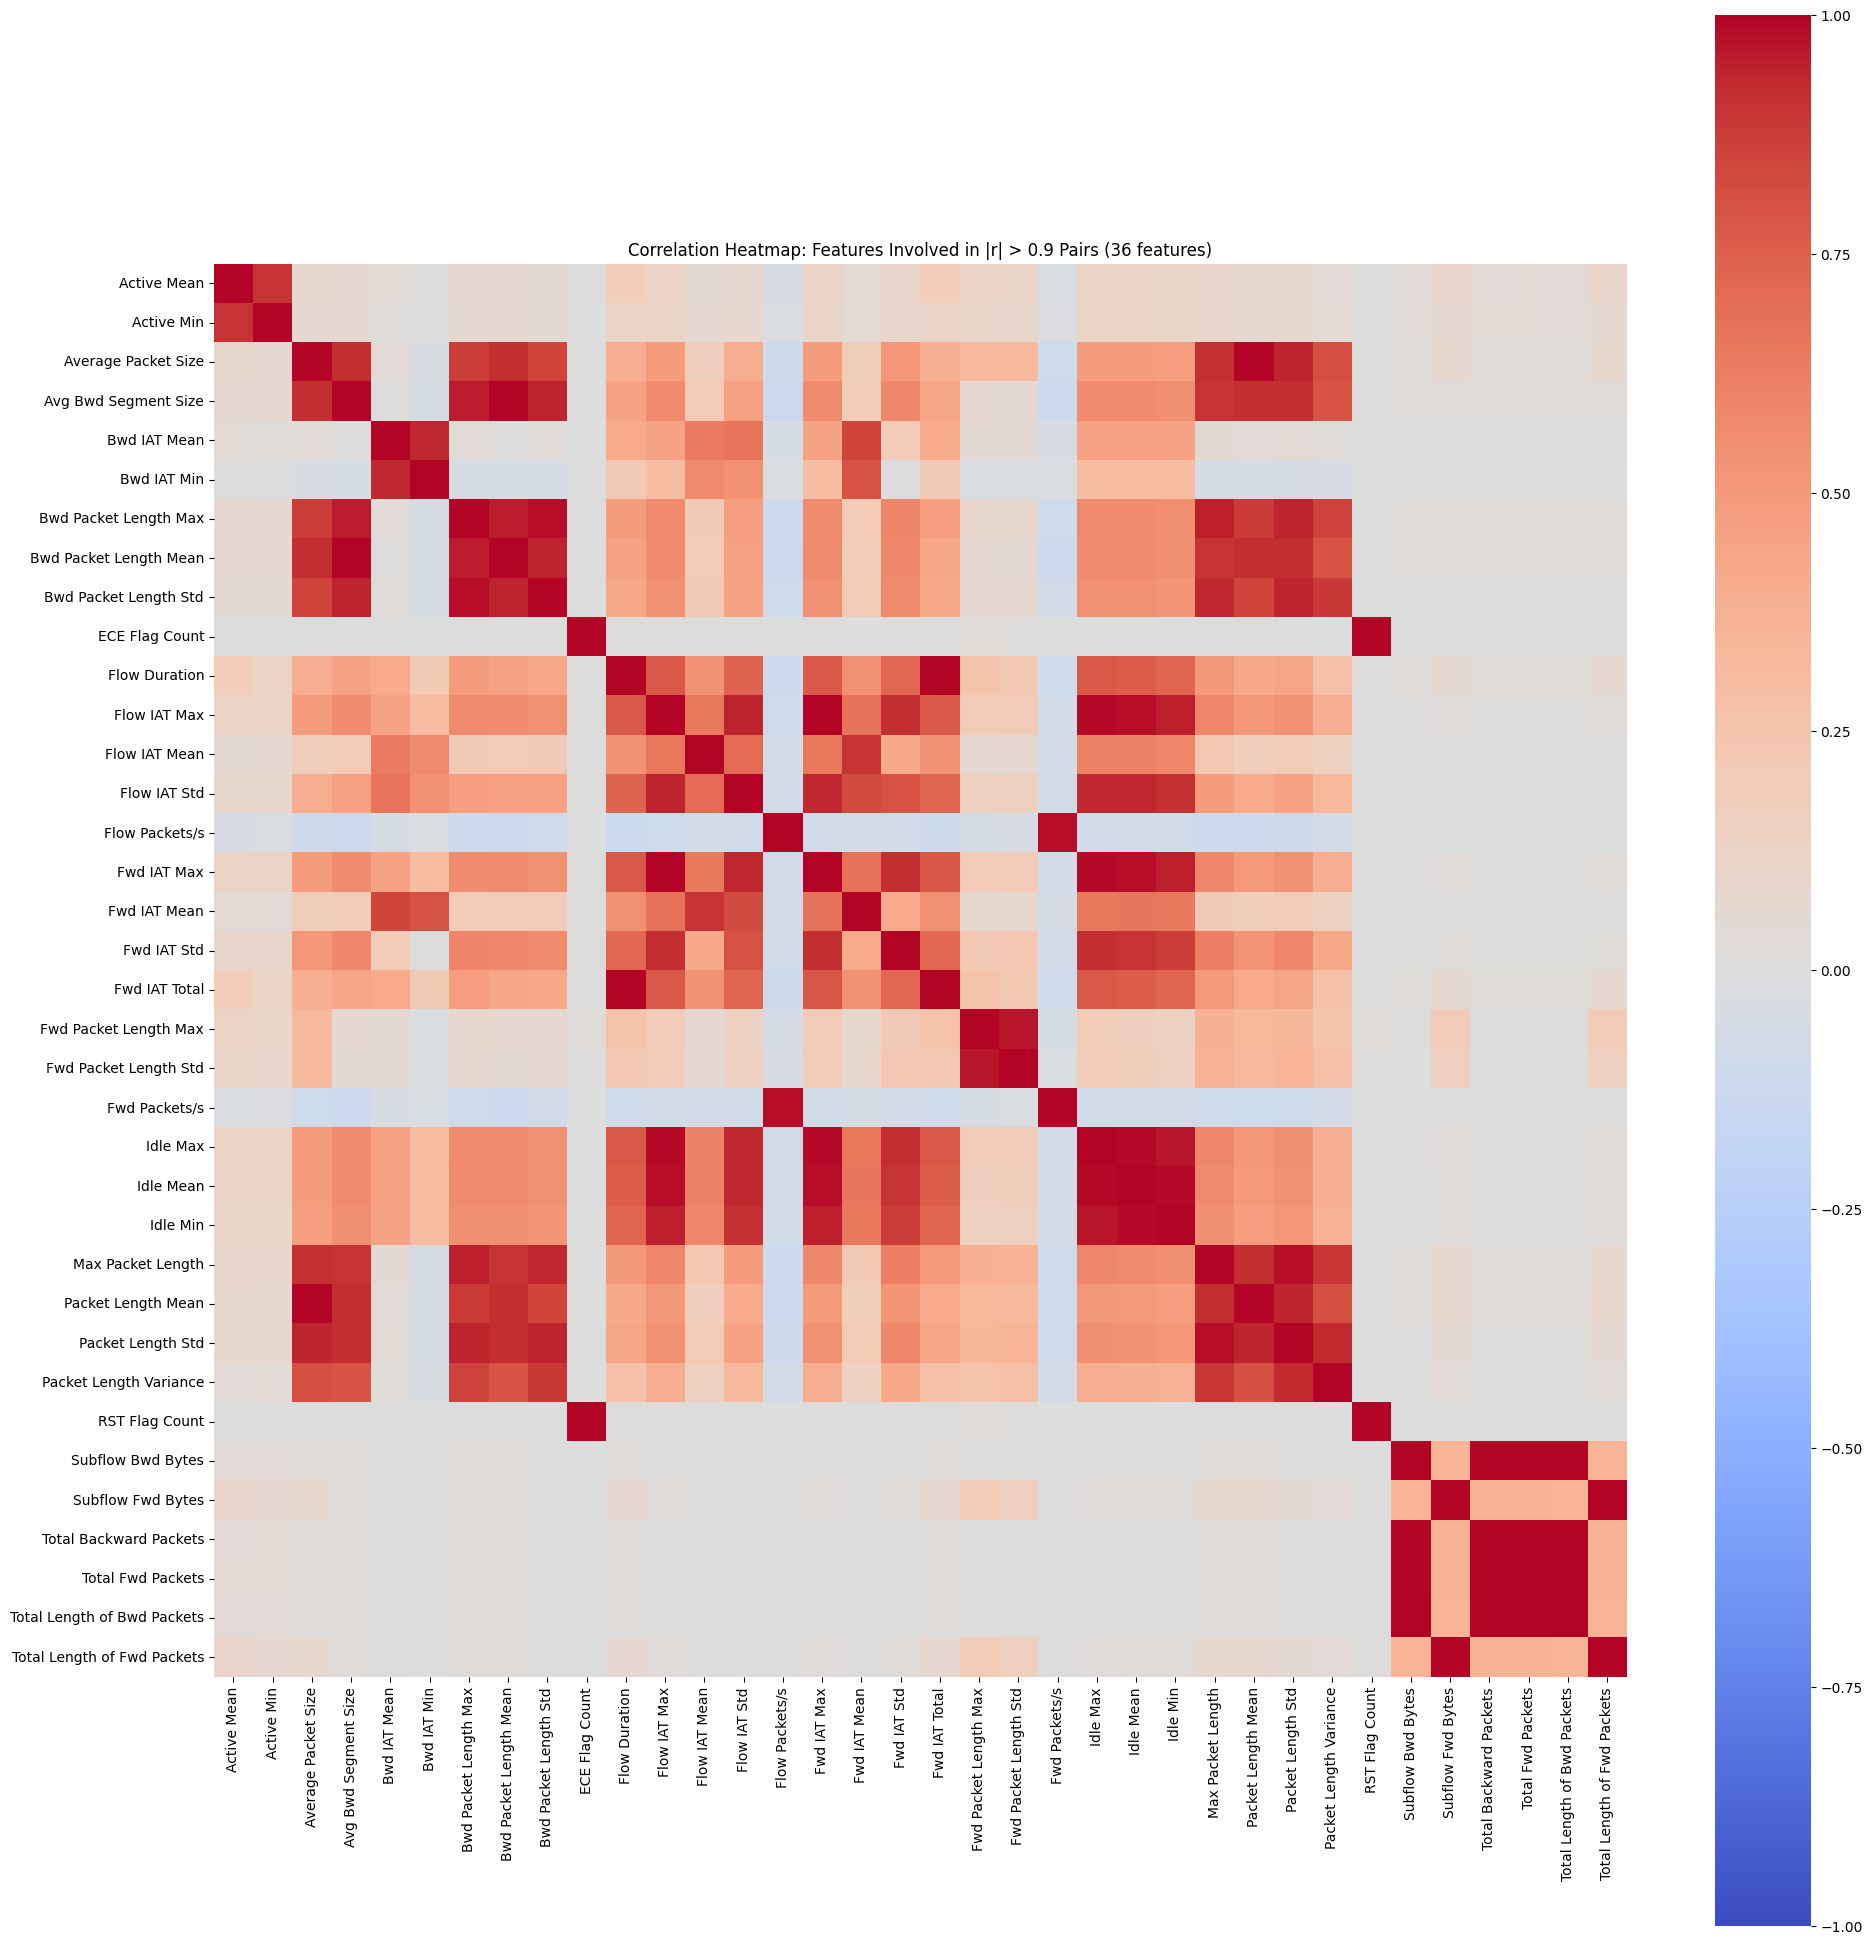


These pairs are candidates to drop one-of-two from later, since they carry largely duplicate information (e.g. 'Subflow Fwd Bytes' repeating 'Total Length of Fwd Packets'). Not dropped yet here, just flagged for now.


In [ ]:
# Heatmap of just the features involved in a high-correlation pair (>0.9), rather than the top-variance features, this makes the redundancy easier to see.
high_corr_features = sorted(set(high_corr_df['Feature 1']).union(high_corr_df['Feature 2']))

plt.figure(figsize=(min(0.5 * len(high_corr_features) + 4, 20),
                     min(0.5 * len(high_corr_features) + 4, 20)))
sns.heatmap(df[high_corr_features].corr(), annot=False, cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title(f'Correlation Heatmap: Features Involved in |r| > {threshold} Pairs '
          f'({len(high_corr_features)} features)')
plt.tight_layout()
plt.show()

print("\nThese pairs are candidates to drop one-of-two from later, since they carry"
      " largely duplicate information (e.g. 'Subflow Fwd Bytes' repeating"
      " 'Total Length of Fwd Packets'). Not dropped yet here, just flagged for now.")

Visualizing top variance features: ['Flow Duration', 'Fwd IAT Total', 'Bwd IAT Total', 'Flow Bytes/s', 'Fwd IAT Max', 'Flow IAT Max', 'Idle Max', 'Idle Mean', 'Idle Min', 'Fwd Header Length', 'Bwd IAT Max', 'Fwd IAT Std']


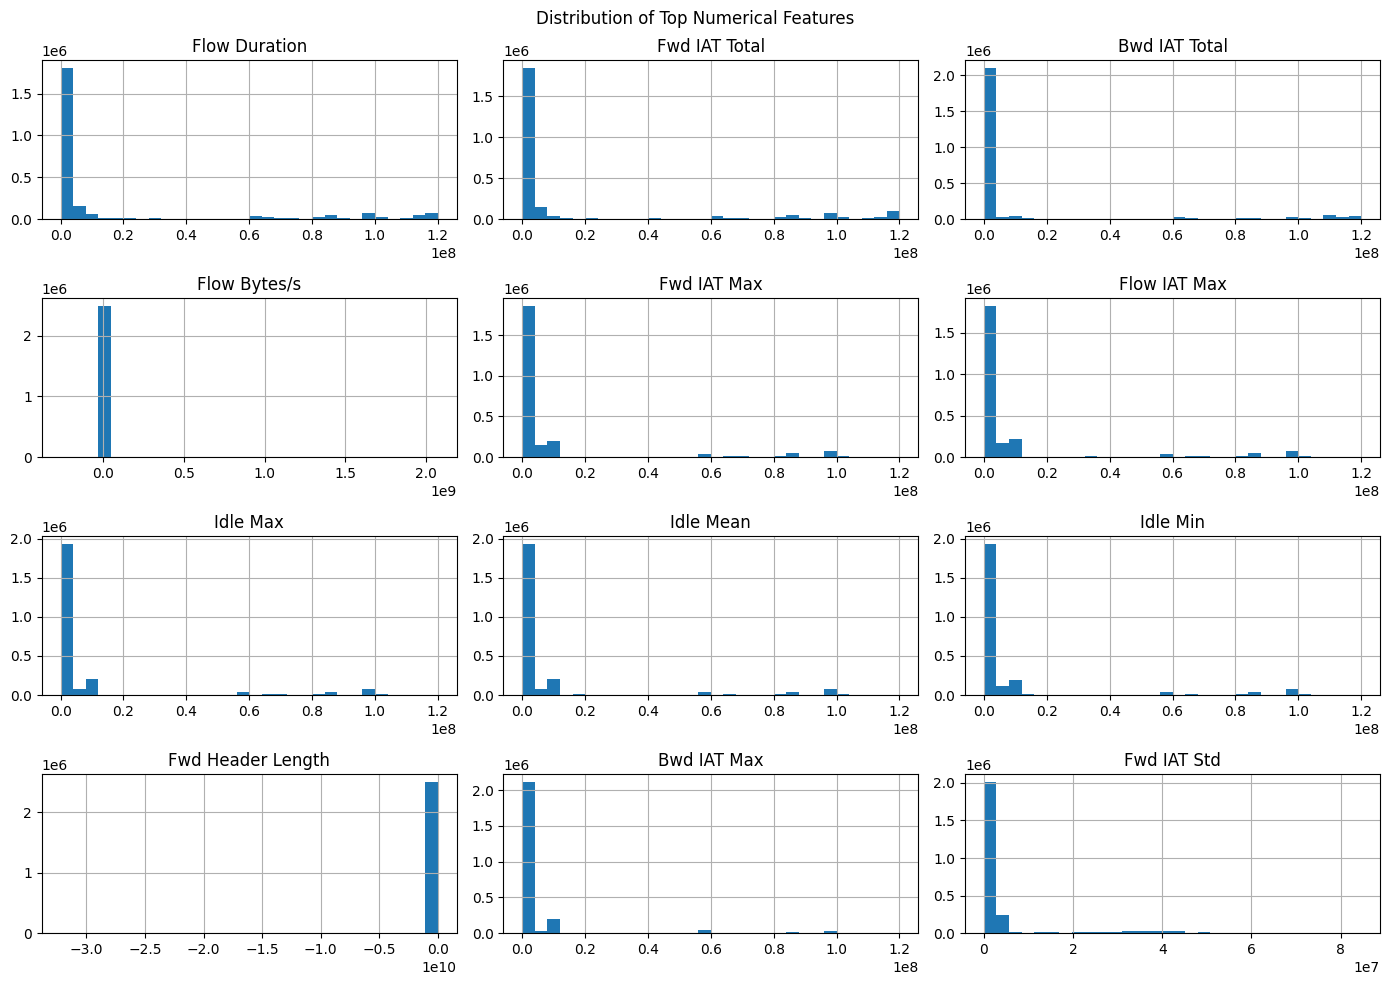

In [ ]:
##For visualization
top_n = 12
feature_variances = df[num_cols].var().sort_values(ascending=False)
top_features = feature_variances.head(top_n).index.tolist()
print("Visualizing top variance features:", top_features)
# ---- Histograms ----
df[top_features].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribution of Top Numerical Features")
plt.tight_layout()
plt.show()


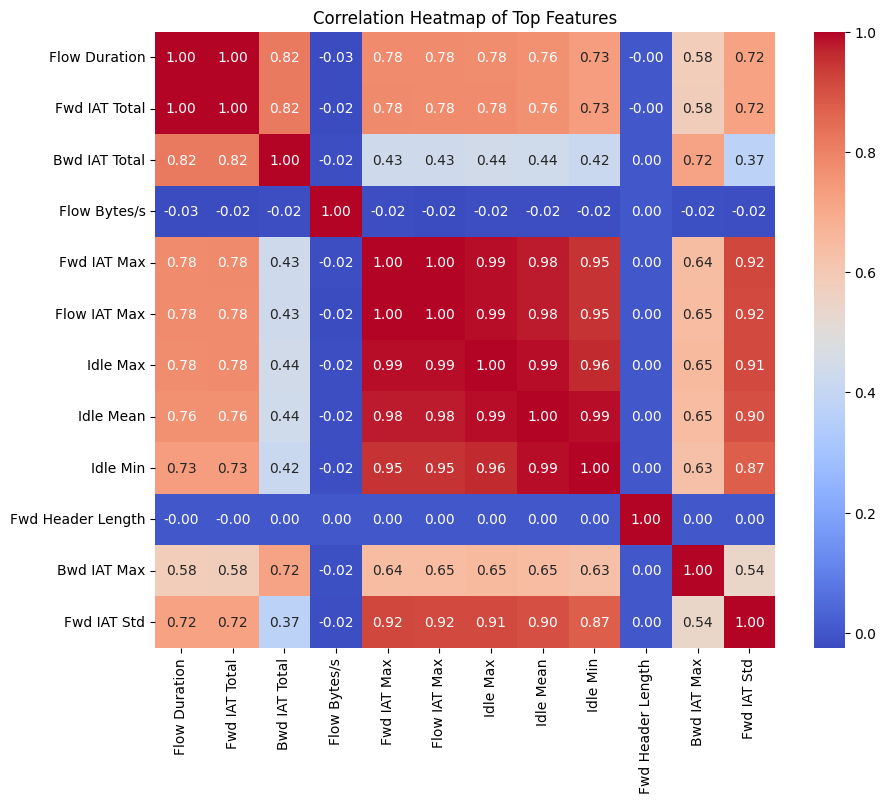

In [ ]:
# ---- Correlation heatmap ----
plt.figure(figsize=(10, 8))
corr = df[top_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Top Features")
plt.show()

**Encoding Label**

In [ ]:
le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])

# Mapping to interpret results
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(label_mapping)


{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack_Brute Force': np.int64(12), 'Web Attack_Sql Injection': np.int64(13), 'Web Attack_XSS': np.int64(14)}


one-hot vs. label encoding for Label

scikit-learn's classifiers (DecisionTreeClassifier, RandomForestClassifier, LogisticRegression, AdaBoostClassifier) all expect the target y to be a single column of class labels (integers or strings), not a one-hot matrix so passing one-hot y into .fit() will error out for these models. SMOTE/undersampling also need a single class-label column to know how many samples belong to each class. So we keep Label_encoded (integer) as the actual y used for training, splitting, and resampling below. Additionally, we build a one-hot encoded version (label_onehot) for anything that specifically wants it like multi-class ROC/AUC curves, per-class probability comparisons, or a future neural-network model with a softmax output.

In [ ]:
# One-hot encoding of Label, kept alongside the integer encoding above. But Not used as y for the sklearn models below, available for metrics/visualizations/neural network model that expects one-hot targets.
label_onehot = pd.get_dummies(df['Label'], prefix='Label')
print("One-hot shape:", label_onehot.shape)
label_onehot.head()

One-hot shape: (2498796, 15)


,Label_BENIGN,Label_Bot,Label_DDoS,Label_DoS GoldenEye,Label_DoS Hulk,Label_DoS Slowhttptest,Label_DoS slowloris,Label_FTP-Patator,Label_Heartbleed,Label_Infiltration,Label_PortScan,Label_SSH-Patator,Label_Web Attack_Brute Force,Label_Web Attack_Sql Injection,Label_Web Attack_XSS
0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Train/Test Split

In [ ]:
X = df.drop(['Label', 'Label_encoded'], axis=1)
y = df['Label_encoded']

#making every feature column numeric
X = X.apply(pd.to_numeric, errors='coerce')
X.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (1999036, 64)
X_test shape: (499760, 64)


In [ ]:
print("X_train shape:", X_train.shape)
print("y_train class counts:\n", pd.Series(y_train).value_counts())


X_train shape: (1999036, 64)
y_train class counts:
 Label_encoded
0     1658442
4      138277
2      102413
10      72555
3        8229
7        4745
6        4308
5        4182
11       2575
1        1558
12       1176
14        521
9          29
13         17
8           9
Name: count, dtype: int64


Handling Class Imbalance

BENIGN has more than 1.6 million training samples but some attack classes like Heartbleed, Infiltration, and Web Attack SQL Injection have fewer than 40 samples. If we train the model directly on this imbalanced data, it may achieve high overall accuracy but perform poorly on the rare attack classes. The model could simply predict BENIGN or the most common attack class most of the time and still perform well.

We cannot balance every class by making them as large as BENIGN. Increasing a class with only 9 real samples to 1.6 million synthetic samples would not be useful. SMOTE creates new samples based on existing nearby samples, so with very few original examples, the generated data may be too similar to the originals. It would also make the training process unnecessarily large and slow.

So, we will use a combined approach only on the training data.

1. Undersampling to reduce the size of the largest classes to a reasonable limit.
2. SMOTE oversampling to increase the smallest classes to a reasonable minimum, rather than trying to match the majority class.

The test set is unchanged to evaluate the model on the original data and get a more realistic measure of how well it may perform on real-world traffic.

In [ ]:
#Install imbalanced-learn
!pip install -q imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import collections

counts_before = collections.Counter(y_train)
print("Class counts before resampling:")
for cls_idx, count in sorted(counts_before.items()):
    print(f"  {le.classes_[cls_idx]:30s} {count}")

# Undersampling any class with more than 50,000 training samples down to 50,000.
undersample_targets = {cls: 50000 for cls, count in counts_before.items() if count > 50000}
undersample = RandomUnderSampler(sampling_strategy=undersample_targets, random_state=42)

#SMOTE so any class with fewer than 1,000 training samples gets oversampled up to 1,000.
# Classes already at or above that are left untouched.
#k_neighbors is capped so SMOTE doesn't fail on classes with very few samples.
smote_targets = {cls: max(count, 1000) for cls, count in counts_before.items() if count < 1000}
min_class_size = min(counts_before.values())
k_neighbors = max(1, min(5, min_class_size - 1))
oversample = SMOTE(sampling_strategy=smote_targets, random_state=42, k_neighbors=k_neighbors)

resample_pipeline = ImbPipeline(steps=[('under', undersample), ('over', oversample)])
X_train_res, y_train_res = resample_pipeline.fit_resample(X_train, y_train)

print("\nClass counts after resampling:")
counts_after = collections.Counter(y_train_res)
for cls_idx, count in sorted(counts_after.items()):
    print(f"  {le.classes_[cls_idx]:30s} {count}")

print("\nResampled training set shape:", X_train_res.shape)


Class counts before resampling:
  BENIGN                         1658442
  Bot                            1558
  DDoS                           102413
  DoS GoldenEye                  8229
  DoS Hulk                       138277
  DoS Slowhttptest               4182
  DoS slowloris                  4308
  FTP-Patator                    4745
  Heartbleed                     9
  Infiltration                   29
  PortScan                       72555
  SSH-Patator                    2575
  Web Attack_Brute Force         1176
  Web Attack_Sql Injection       17
  Web Attack_XSS                 521

Class counts after resampling:
  BENIGN                         50000
  Bot                            1558
  DDoS                           50000
  DoS GoldenEye                  8229
  DoS Hulk                       50000
  DoS Slowhttptest               4182
  DoS slowloris                  4308
  FTP-Patator                    4745
  Heartbleed                     1000
  Infiltration       

# MODELLING IMPLEMENTATION

From-Scratch Model Implementations

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None


In [ ]:
class DecisionTree:
    def __init__(self, max_depth=None, n_thresholds=10):
        self.max_depth = max_depth
        self.n_thresholds = n_thresholds  # number of percentile thresholds tested per feature
        self.root = None

    def fit(self, X, y, depth=0):
        if len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth) or len(y) < 2:
            node = Node(value=self._majority_class(y))
            if depth == 0:
                self.root = node
            return node

        best_feature, best_threshold = self.find_best_split(X, y)
        if best_feature is None:
            node = Node(value=self._majority_class(y))
            if depth == 0:
                self.root = node
            return node

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        if left_mask.sum() == 0 or right_mask.sum() == 0:
            node = Node(value=self._majority_class(y))
            if depth == 0:
                self.root = node
            return node

        left_node = self.fit(X[left_mask], y[left_mask], depth + 1)
        right_node = self.fit(X[right_mask], y[right_mask], depth + 1)

        node = Node(feature=best_feature, threshold=best_threshold, left=left_node, right=right_node)
        if depth == 0:
            self.root = node
        return node

    def find_best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        for feature in range(n_features):
            values = X[:, feature]
            candidate_thresholds = np.unique(np.percentile(values, np.linspace(1, 99, self.n_thresholds)))

            for threshold in candidate_thresholds:
                left_mask = values <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                gini = self._weighted_gini(y[left_mask], y[right_mask])
                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def gini_impurity(self, y):
        if len(y) == 0:
            return 0
        _, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return 1 - np.sum(probabilities ** 2)

    def _weighted_gini(self, y_left, y_right):
        n = len(y_left) + len(y_right)
        return (len(y_left)/n) * self.gini_impurity(y_left) + (len(y_right)/n) * self.gini_impurity(y_right)

    def _majority_class(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, node, x):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict(node.left, x)
        else:
            return self.predict(node.right, x)


In [ ]:
X_train_full = X_train_res.to_numpy() if hasattr(X_train_res, 'to_numpy') else np.asarray(X_train_res)
y_train_full = y_train_res.to_numpy() if hasattr(y_train_res, 'to_numpy') else np.asarray(y_train_res)
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

sample_size = 6000
if len(y_train_full) > sample_size:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full,
        train_size=sample_size, stratify=y_train_full, random_state=42
    )
else:
    X_sub, y_sub = X_train_full, y_train_full

print("From scratch training set size:", X_sub.shape)

From scratch training set size: (6000, 64)


In [ ]:
decision_tree = DecisionTree(max_depth=10, n_thresholds=10)
final_tree = decision_tree.fit(X_sub, y_sub)

y_pred_dt_scr = np.array([decision_tree.predict(final_tree, instance) for instance in X_test_np])
accuracy_dt_scr = np.sum(y_pred_dt_scr == y_test_np) / len(y_test_np)
print("Decision Tree (from scratch) Accuracy:", accuracy_dt_scr)

Decision Tree (from scratch) Accuracy: 0.967942612453978


In [ ]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=10, n_thresholds=10):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.n_thresholds = n_thresholds
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = X.shape[0]
        for _ in range(self.n_estimators):
            indices = np.random.choice(n_samples, size=n_samples, replace=True)
            X_sample, y_sample = X[indices], y[indices]

            dt_model = DecisionTree(max_depth=self.max_depth, n_thresholds=self.n_thresholds)
            tree_root = dt_model.fit(X_sample, y_sample)
            self.trees.append((dt_model, tree_root))

    def predict(self, X):
        tree_predictions = []
        for dt_model, tree_root in self.trees:
            preds = [dt_model.predict(tree_root, instance) for instance in X]
            tree_predictions.append(preds)
        tree_predictions = np.array(tree_predictions)

        final_predictions = []
        for i in range(X.shape[0]):
            votes = tree_predictions[:, i]
            final_predictions.append(self._majority_vote(votes))
        return np.array(final_predictions)

    def _majority_vote(self, votes):
        values, counts = np.unique(votes, return_counts=True)
        return values[np.argmax(counts)]


In [ ]:
random_forest = RandomForest(n_estimators=10, max_depth=10, n_thresholds=10)
random_forest.fit(X_sub, y_sub)

y_pred_rf_scr = random_forest.predict(X_test_np)
accuracy_rf_scr = np.sum(y_pred_rf_scr == y_test_np) / len(y_test_np)
print("Random Forest (from scratch) Accuracy:", accuracy_rf_scr)

Random Forest (from scratch) Accuracy: 0.9882843765007203


Using sklearn Library

Logistic Regression is trained on a smaller 200,000 row sample of the resampled training data to keep the training time manageable. Decision Tree and Random Forest are efficient enough to train on the entire resampled dataset.


In [ ]:
sklearn_sample_size = 200000
if len(y_train_res) > sklearn_sample_size:
    X_train_sk, _, y_train_sk, _ = train_test_split(
        X_train_res, y_train_res,
        train_size=sklearn_sample_size, stratify=y_train_res, random_state=42
    )
else:
    X_train_sk, y_train_sk = X_train_res, y_train_res

print("sklearn training subsample:", X_train_sk.shape)


sklearn training subsample: (200000, 64)


In [ ]:
# Feature Scaling for Logistic Regression
scaler = StandardScaler()
X_train_sk_scaled = scaler.fit_transform(X_train_sk)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#Logistic Regression
t0 = time.time()
logistic_model = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
logistic_model.fit(X_train_sk_scaled, y_train_sk)
y_pred_lr = logistic_model.predict(X_test_scaled)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} (took {time.time()-t0:.1f}s)")


Logistic Regression Accuracy: 0.9469 (took 52.6s)


In [ ]:
import time

t0 = time.time()
decision_tree_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
decision_tree_model.fit(X_train_res, y_train_res)
y_pred_dt = decision_tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(f"DT fit took {time.time()-t0:.1f}s")


Decision Tree Accuracy: 0.9938750600288139
DT fit took 7.1s


In [ ]:
t0 = time.time()
random_forest_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_forest_model.fit(X_train_res, y_train_res)
y_pred_rf = random_forest_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(f"RF fit took {time.time()-t0:.1f}s")


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   26.6s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   29.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Random Forest Accuracy: 0.9972526812870177
RF fit took 33.2s


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    3.7s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    3.9s finished


In [ ]:
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    414611
                     Bot       0.68      0.92      0.78       390
                    DDoS       1.00      1.00      1.00     25603
           DoS GoldenEye       0.98      0.99      0.99      2057
                DoS Hulk       0.99      1.00      0.99     34569
        DoS Slowhttptest       0.93      0.98      0.96      1046
           DoS slowloris       0.99      0.99      0.99      1077
             FTP-Patator       1.00      1.00      1.00      1186
              Heartbleed       1.00      1.00      1.00         2
            Infiltration       1.00      0.71      0.83         7
                PortScan       0.99      1.00      0.99     18139
             SSH-Patator       0.99      0.97      0.98       644
  Web Attack_Brute Force       0.78      0.49      0.60       294
Web Attack_Sql Injection       0.16      0.75      0.26         4
         

In [ ]:
#AdaBoost
t0 = time.time()
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)
adaboost_model.fit(X_train_sk, y_train_sk)
y_pred_ada = adaboost_model.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_ada):.4f} (took {time.time()-t0:.1f}s)")

AdaBoost Accuracy: 0.9868 (took 164.4s)


## Neural Network Models

Two neural networks used.
1. **MLPClassifier (scikit-learn)** is a straightforward feedforward network, trained the same way as Logistic Regression above (same 200k scaled subsample), so it's directly comparable.
2. **Keras Sequential network** is a slightly deeper network with dropout, trained using the one-hot encoded labels built earlier, giving a real use for `label_onehot`/one-hot targets.

In [ ]:
# --- Neural Network 1: MLPClassifier (scikit-learn) ---
from sklearn.neural_network import MLPClassifier

t0 = time.time()
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=100,
    early_stopping=True,
    random_state=42
)
mlp_model.fit(X_train_sk_scaled, y_train_sk)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print(f"MLPClassifier Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f} (took {time.time()-t0:.1f}s)")


MLPClassifier Accuracy: 0.9922 (took 299.1s)


**Keras network setup.** This trains on the same 200,000-row scaled subsample used for Logistic Regression and the MLPClassifier above (X_train_sk_scaled, y_train_sk), so results are comparable across all three. Labels are converted to one-hot here with to_categorical. This is the same idea as label_onehot built earlier, just re-derived for this specific subsample/split rather than reusing the full-dataset version.

In [ ]:
# --- Neural Network 2: Keras Sequential feedforward network ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

n_classes = len(le.classes_)
y_train_sk_onehot = to_categorical(y_train_sk, num_classes=n_classes)
y_test_onehot = to_categorical(y_test, num_classes=n_classes)

tf.random.set_seed(42)
keras_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sk_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

keras_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
history = keras_model.fit(
    X_train_sk_scaled, y_train_sk_onehot,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    verbose=1
)

y_pred_nn_proba = keras_model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_proba, axis=1)
print(f"Keras NN Accuracy: {accuracy_score(y_test, y_pred_nn):.4f} (took {time.time()-t0:.1f}s)")


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8897 - loss: 0.4132 - val_accuracy: 0.9520 - val_loss: 0.1491
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9500 - loss: 0.1712 - val_accuracy: 0.9645 - val_loss: 0.1089
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9595 - loss: 0.1316 - val_accuracy: 0.9711 - val_loss: 0.0919
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9649 - loss: 0.1149 - val_accuracy: 0.9721 - val_loss: 0.0857
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9683 - loss: 0.1032 - val_accuracy: 0.9750 - val_loss: 0.0771
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9705 - loss: 0.0951 - val_accuracy: 0.9758 - val_loss: 0.0748
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9717 - loss: 0.0909 - val_accuracy: 0.9762 - val_loss: 0.0711
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9725 - loss: 0.0870 - val_accuracy: 0.

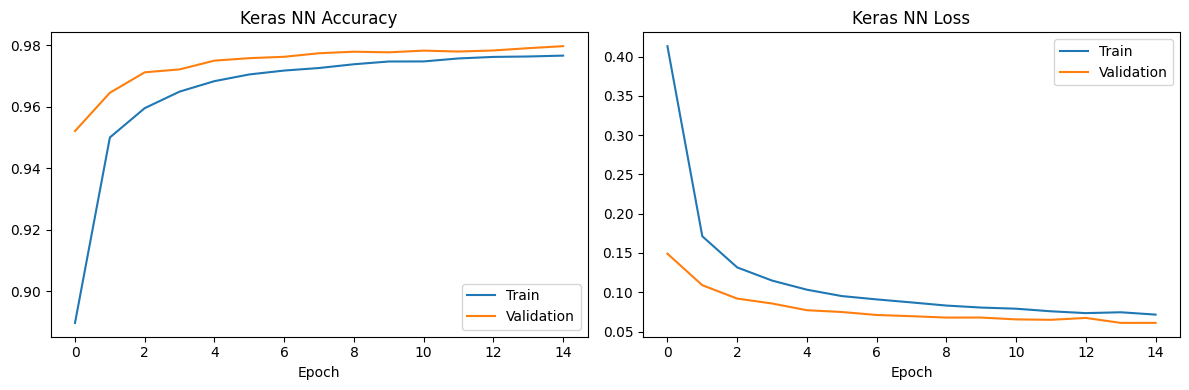

In [ ]:
# Training curves: useful to check for overfitting (train vs. validation diverging)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Keras NN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Keras NN Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
X_train_full = X_train.to_numpy()
y_train_full = y_train.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

In [ ]:
sample_size = 6000  # adjusted between 5000-8000 based on how fast Colab runs
if len(y_train_full) > sample_size:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_full, y_train_full,
        train_size=sample_size, stratify=y_train_full, random_state=42
    )
else:
    X_sub, y_sub = X_train_full, y_train_full

print("From scratch training set size:", X_sub.shape)

From scratch training set size: (6000, 64)


Since the dataset is highly imbalanced so accuracy alone is misleading.

So we are using confusion matrix to know which model detects which attacks well.

Confusion Matrix (Without normalization)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix_raw(y_true, y_pred, labels, title):
    fig, ax = plt.subplots(figsize=(14, 12))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=labels,
        normalize=None,        # raw counts, not proportions
        cmap="Blues",
        xticks_rotation=75,
        ax=ax,
        values_format='d',     # integers instead of decimals
        colorbar=True
    )
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

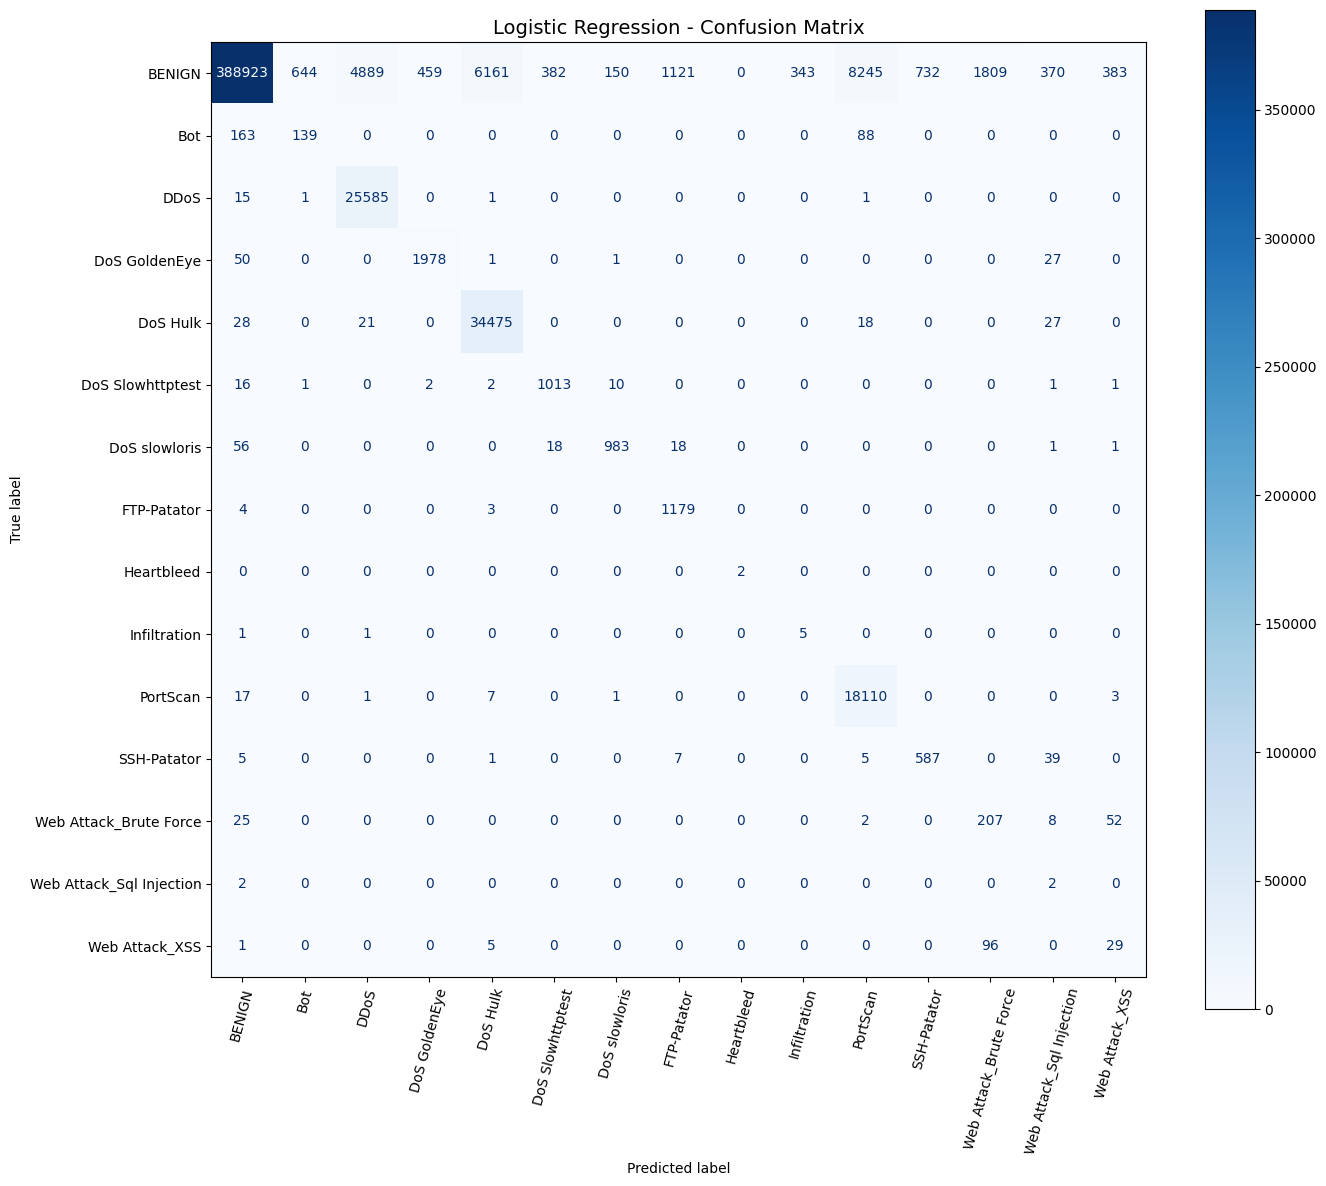

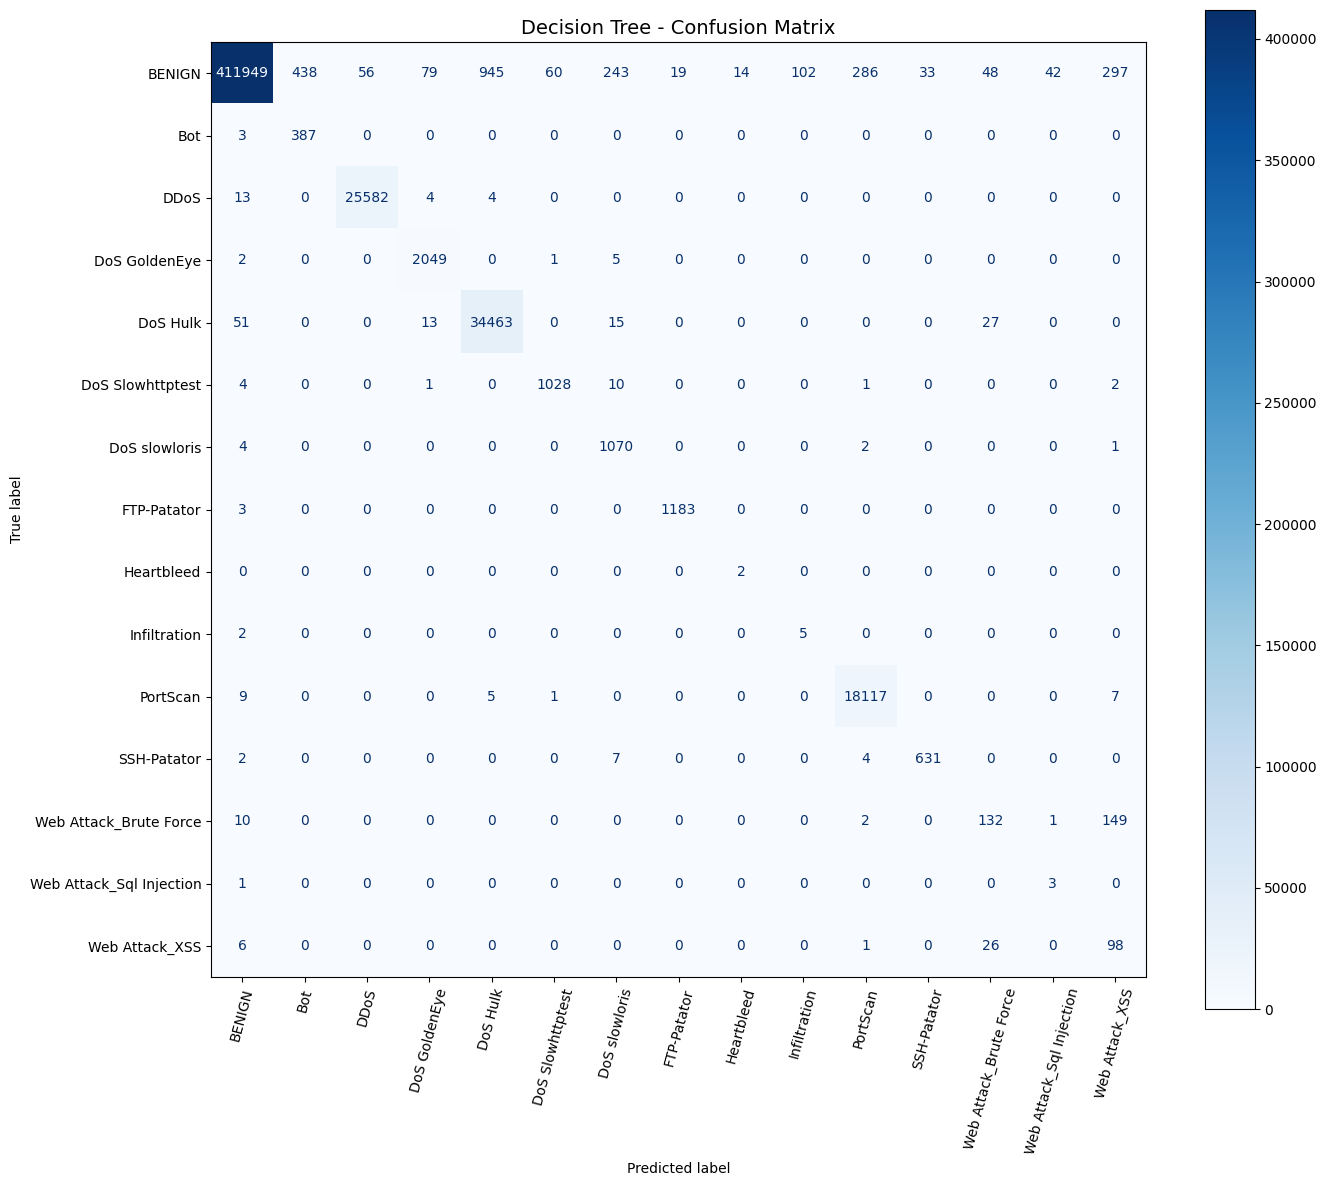

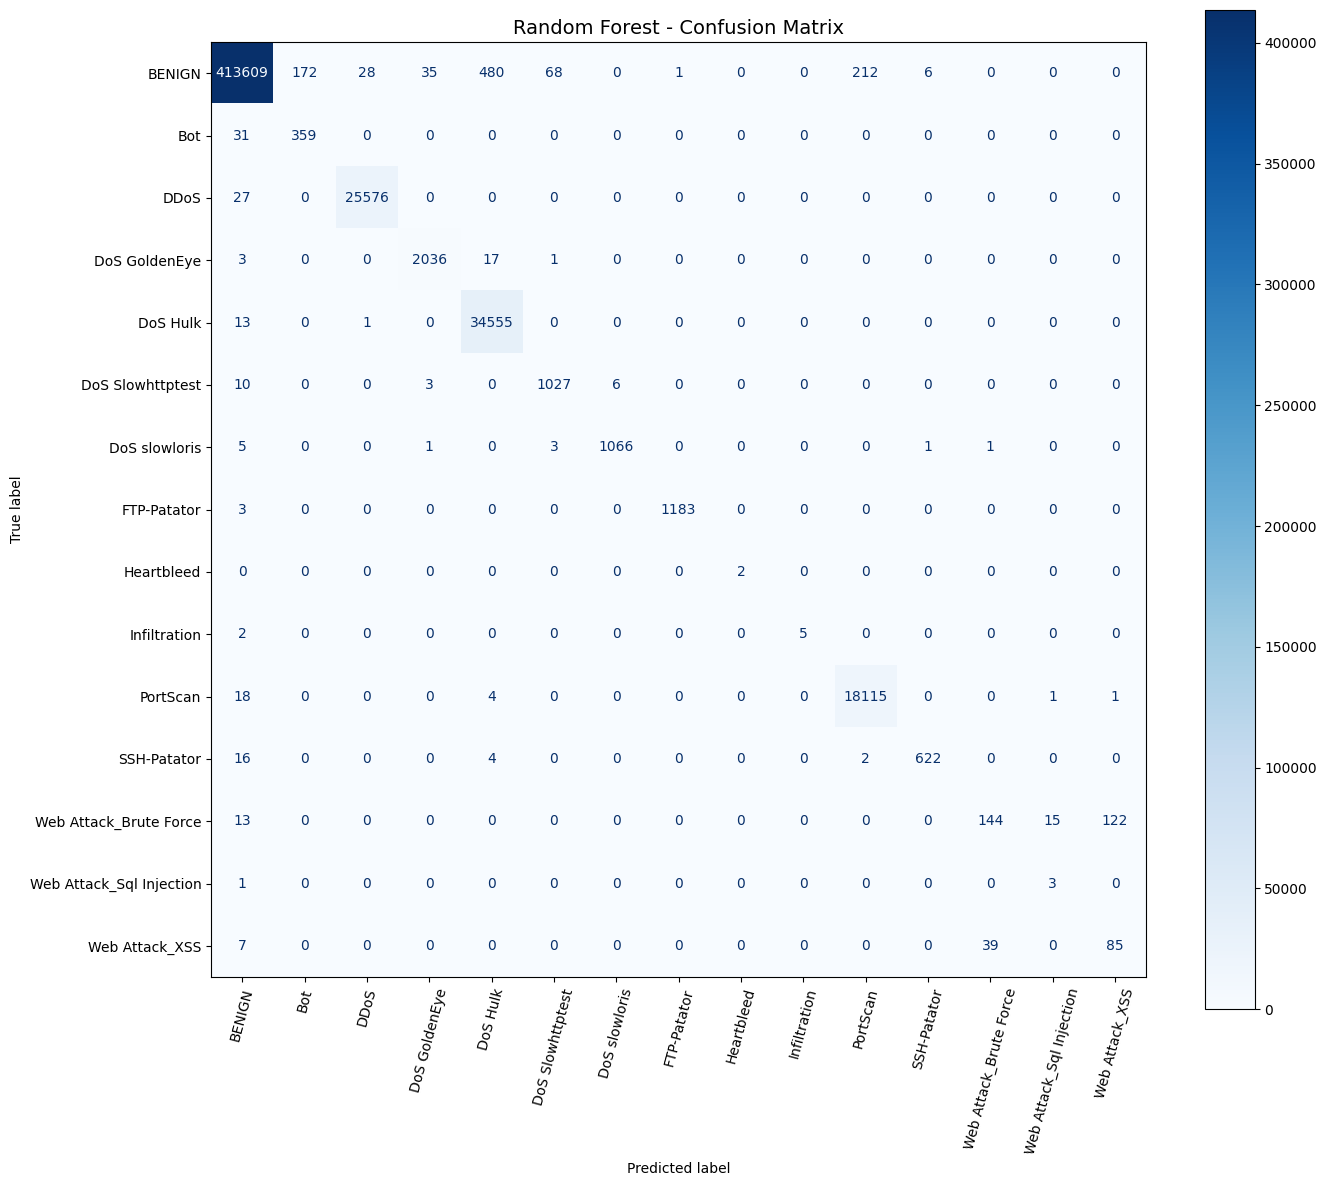

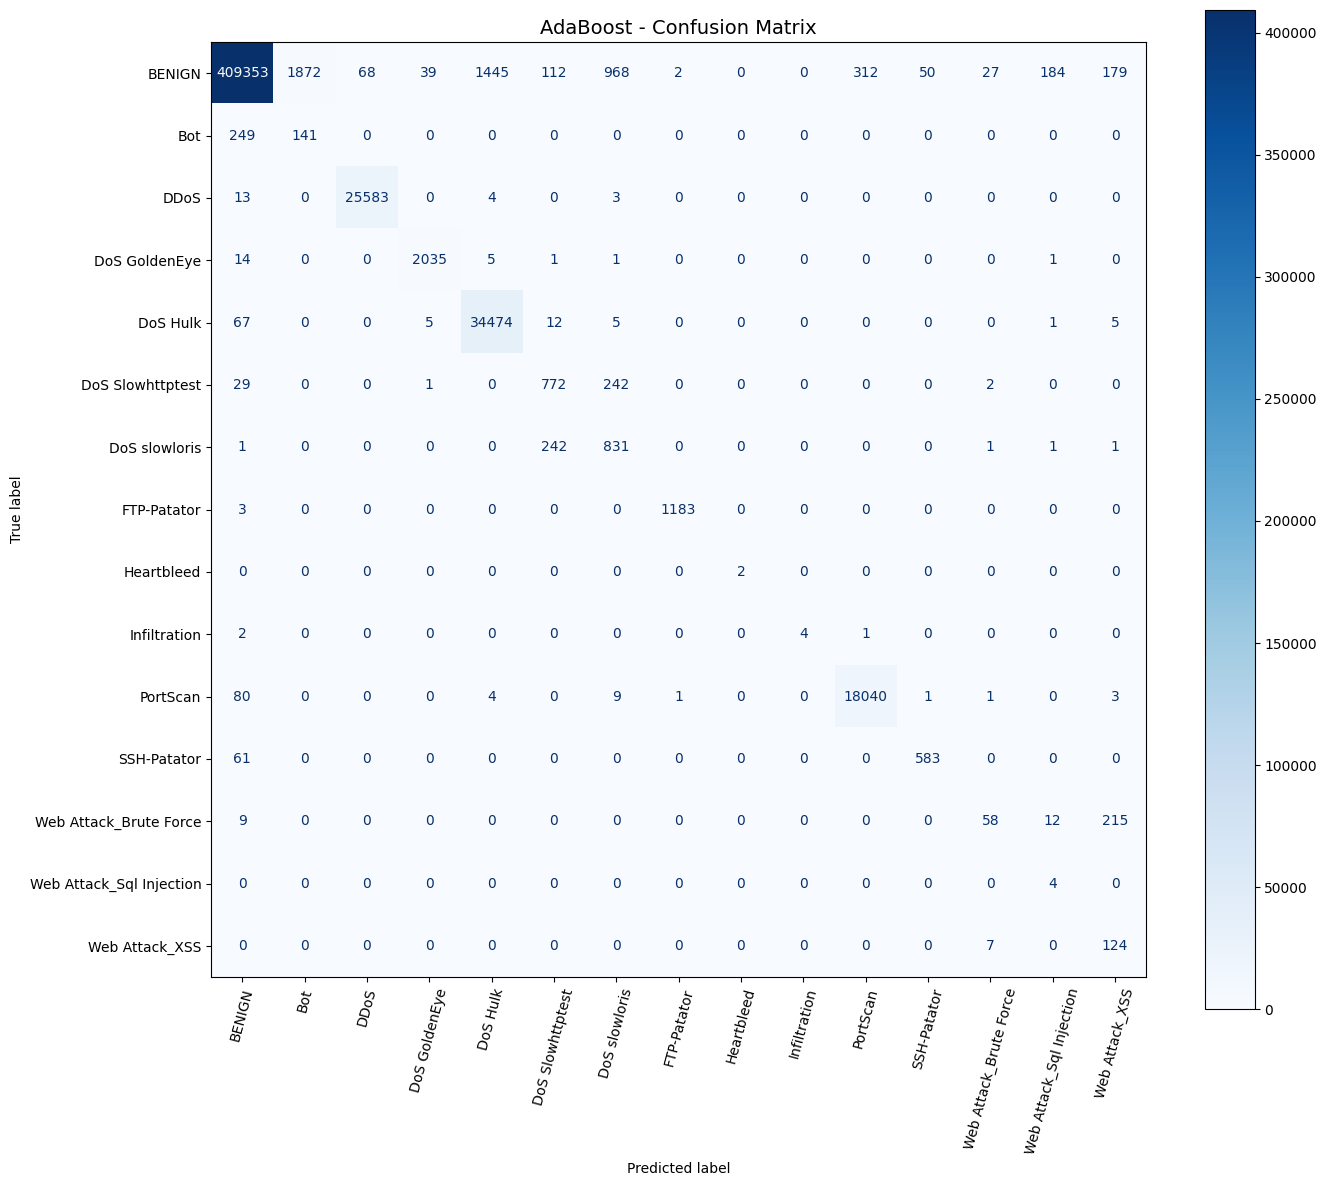

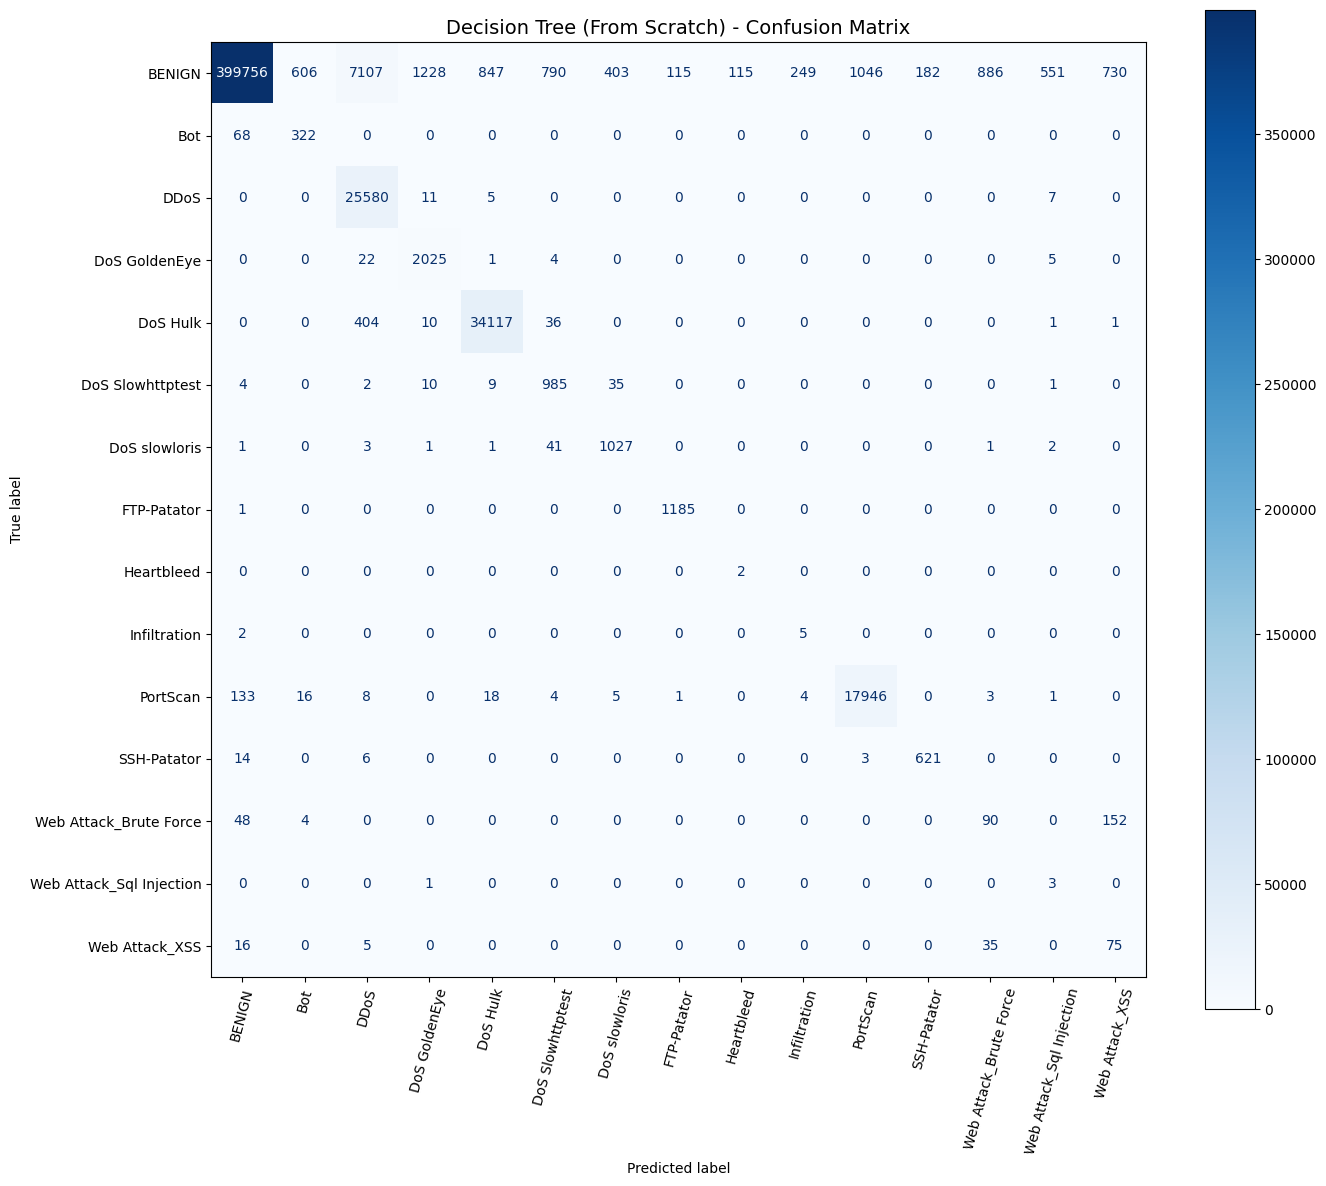

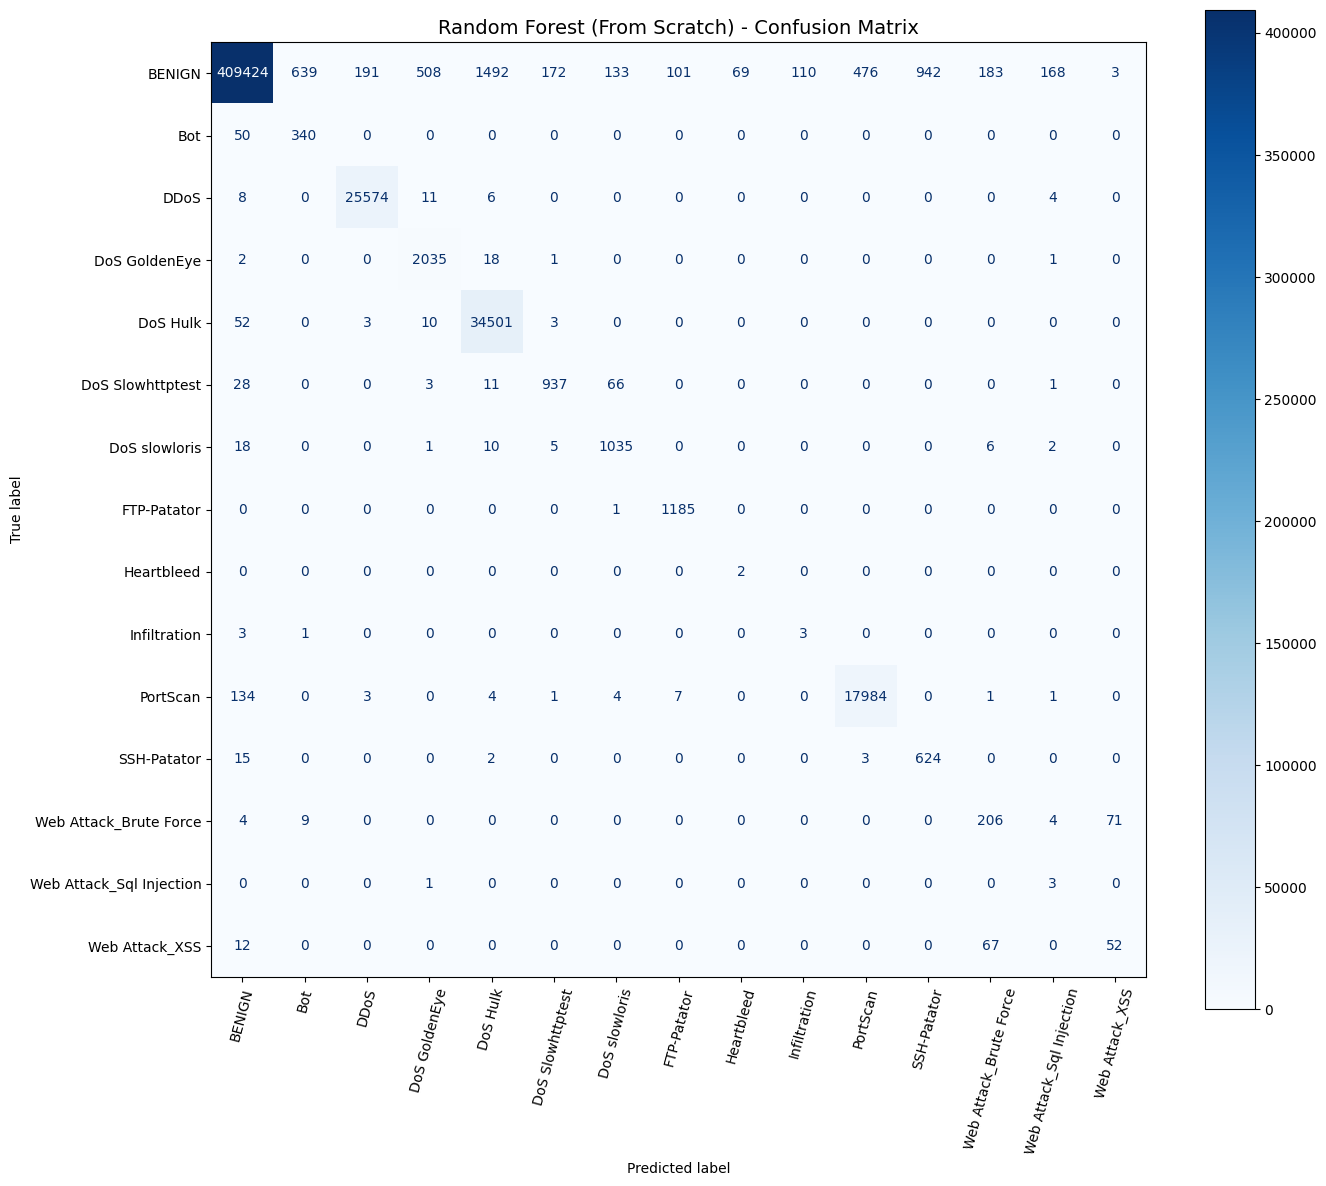

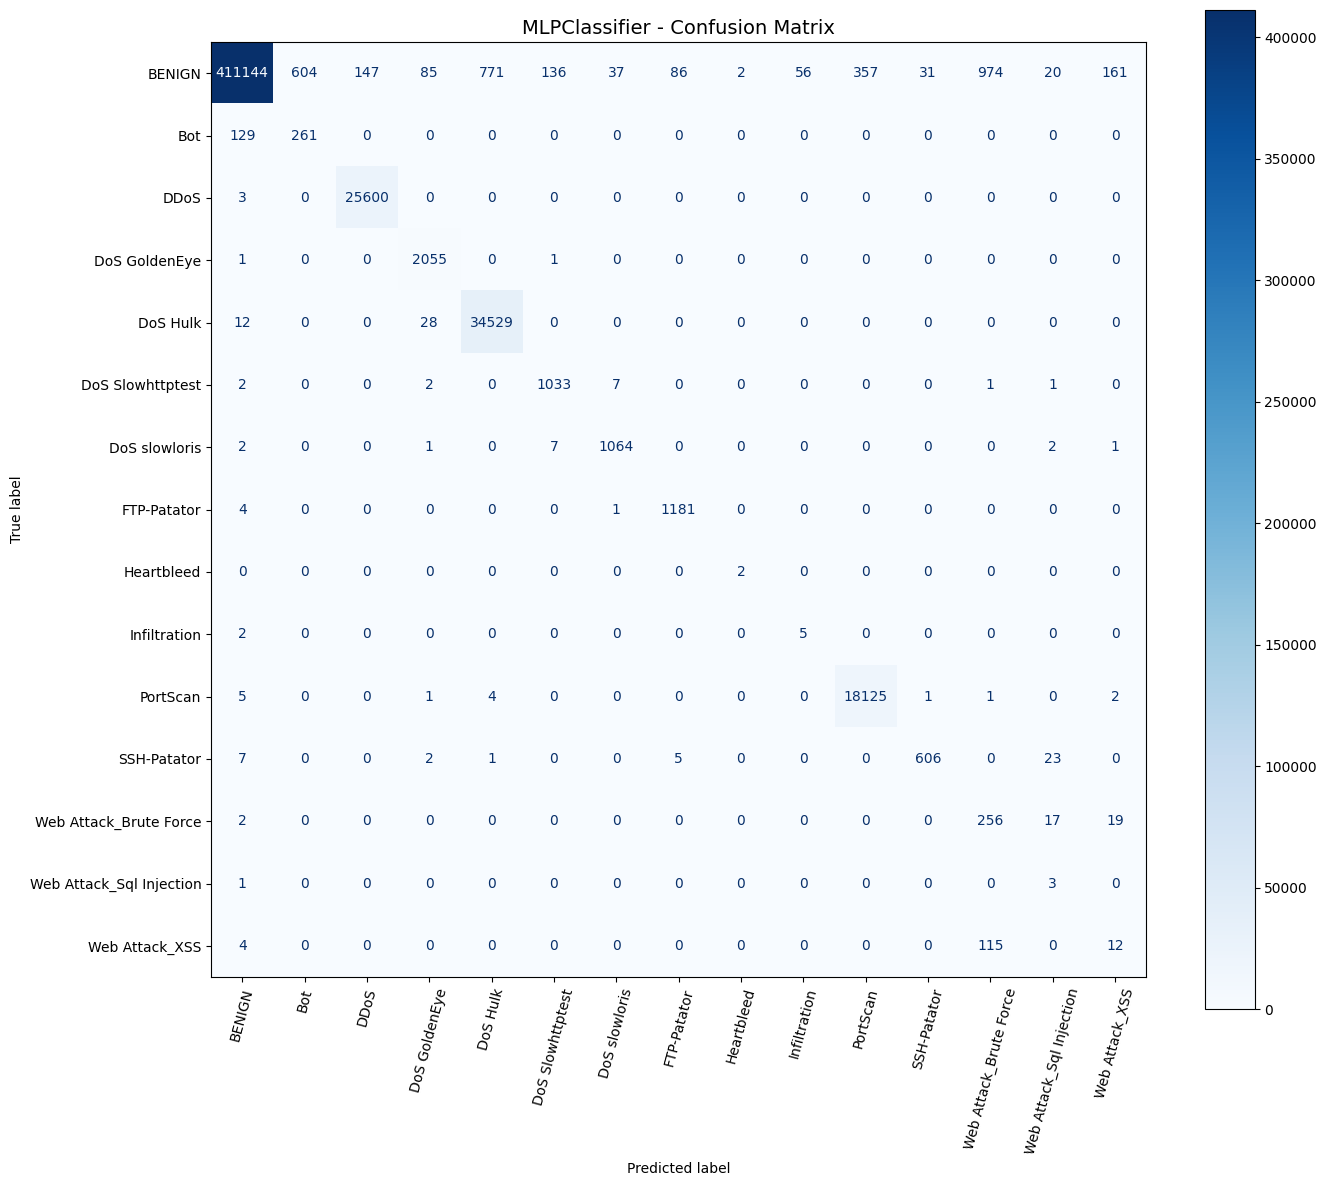

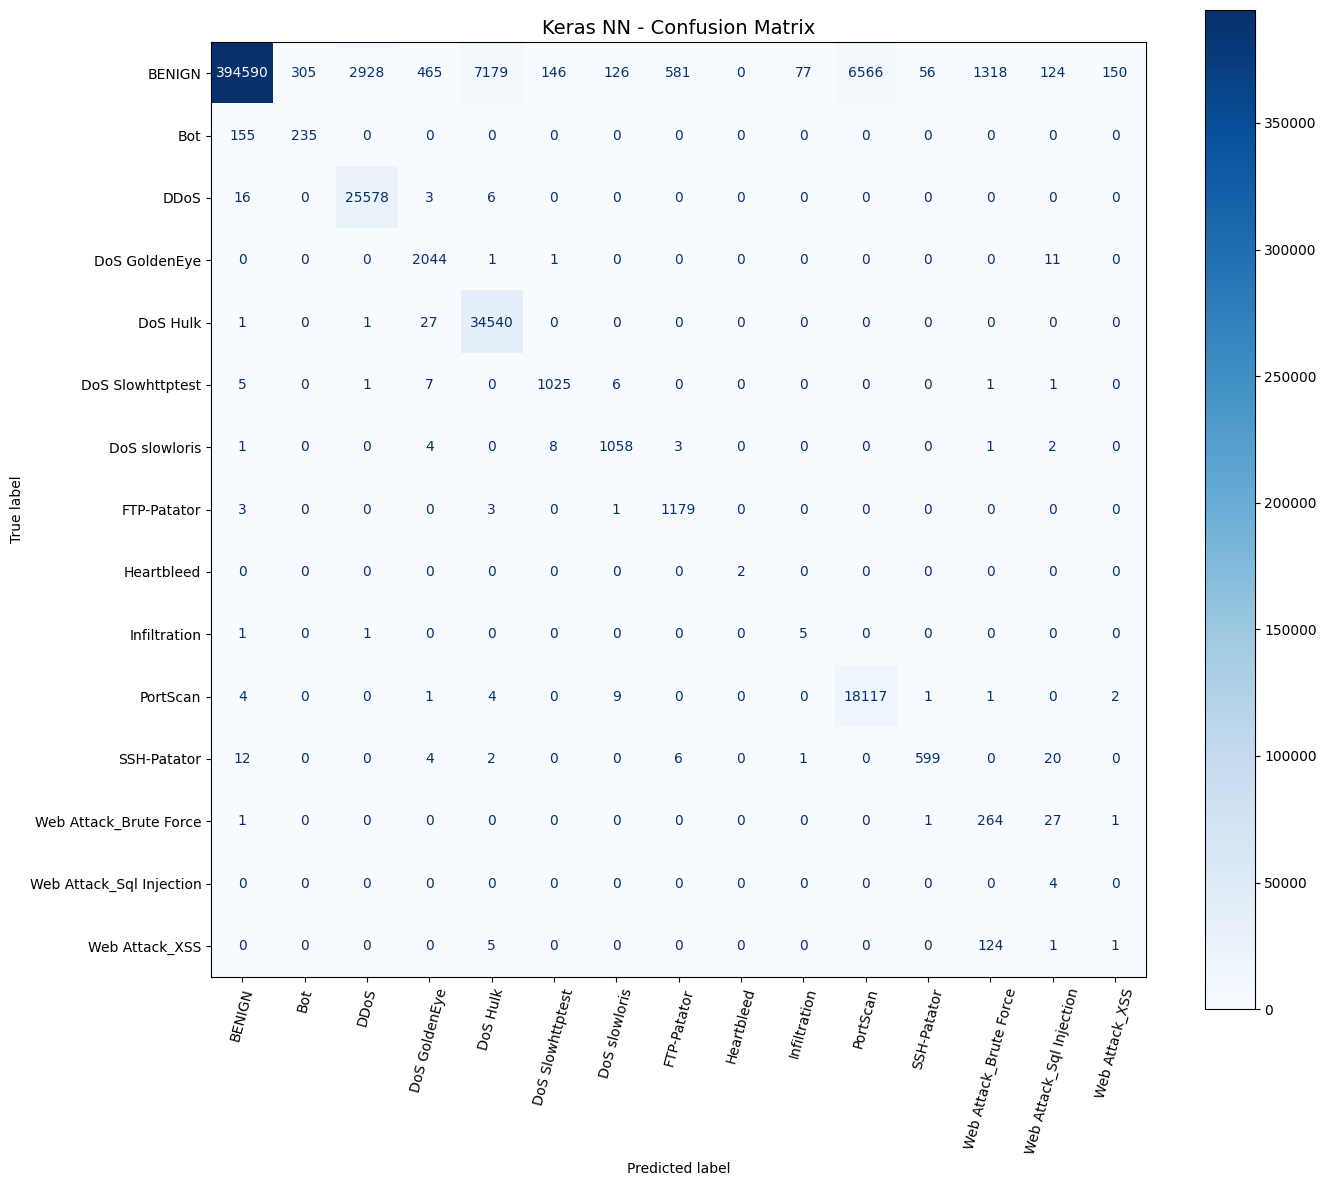

In [ ]:
# Logistic Regression
plot_confusion_matrix_raw(y_test, y_pred_lr, le.classes_, "Logistic Regression - Confusion Matrix")

# Decision Tree
plot_confusion_matrix_raw(y_test, y_pred_dt, le.classes_, "Decision Tree - Confusion Matrix")

# Random Forest
plot_confusion_matrix_raw(y_test, y_pred_rf, le.classes_, "Random Forest - Confusion Matrix")

# AdaBoost
plot_confusion_matrix_raw(y_test, y_pred_ada, le.classes_, "AdaBoost - Confusion Matrix")

# From-scratch Decision Tree
plot_confusion_matrix_raw(y_test_np, y_pred_dt_scr, le.classes_, "Decision Tree (From Scratch) - Confusion Matrix")

# From-scratch Random Forest
plot_confusion_matrix_raw(y_test_np, y_pred_rf_scr, le.classes_, "Random Forest (From Scratch) - Confusion Matrix")

# MLPClassifier
plot_confusion_matrix_raw(y_test, y_pred_mlp, le.classes_, "MLPClassifier - Confusion Matrix")

# Keras NN
plot_confusion_matrix_raw(y_test, y_pred_nn, le.classes_, "Keras NN - Confusion Matrix")


NORMALIZED Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred, labels, title):
    fig, ax = plt.subplots(figsize=(14, 12))  # bigger canvas = no overlap
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=labels,
        normalize='true',
        cmap="Blues",
        xticks_rotation=75,
        ax=ax,
        values_format='.2f',      # cleaner 2-decimal numbers instead of long floats
        colorbar=True
    )
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

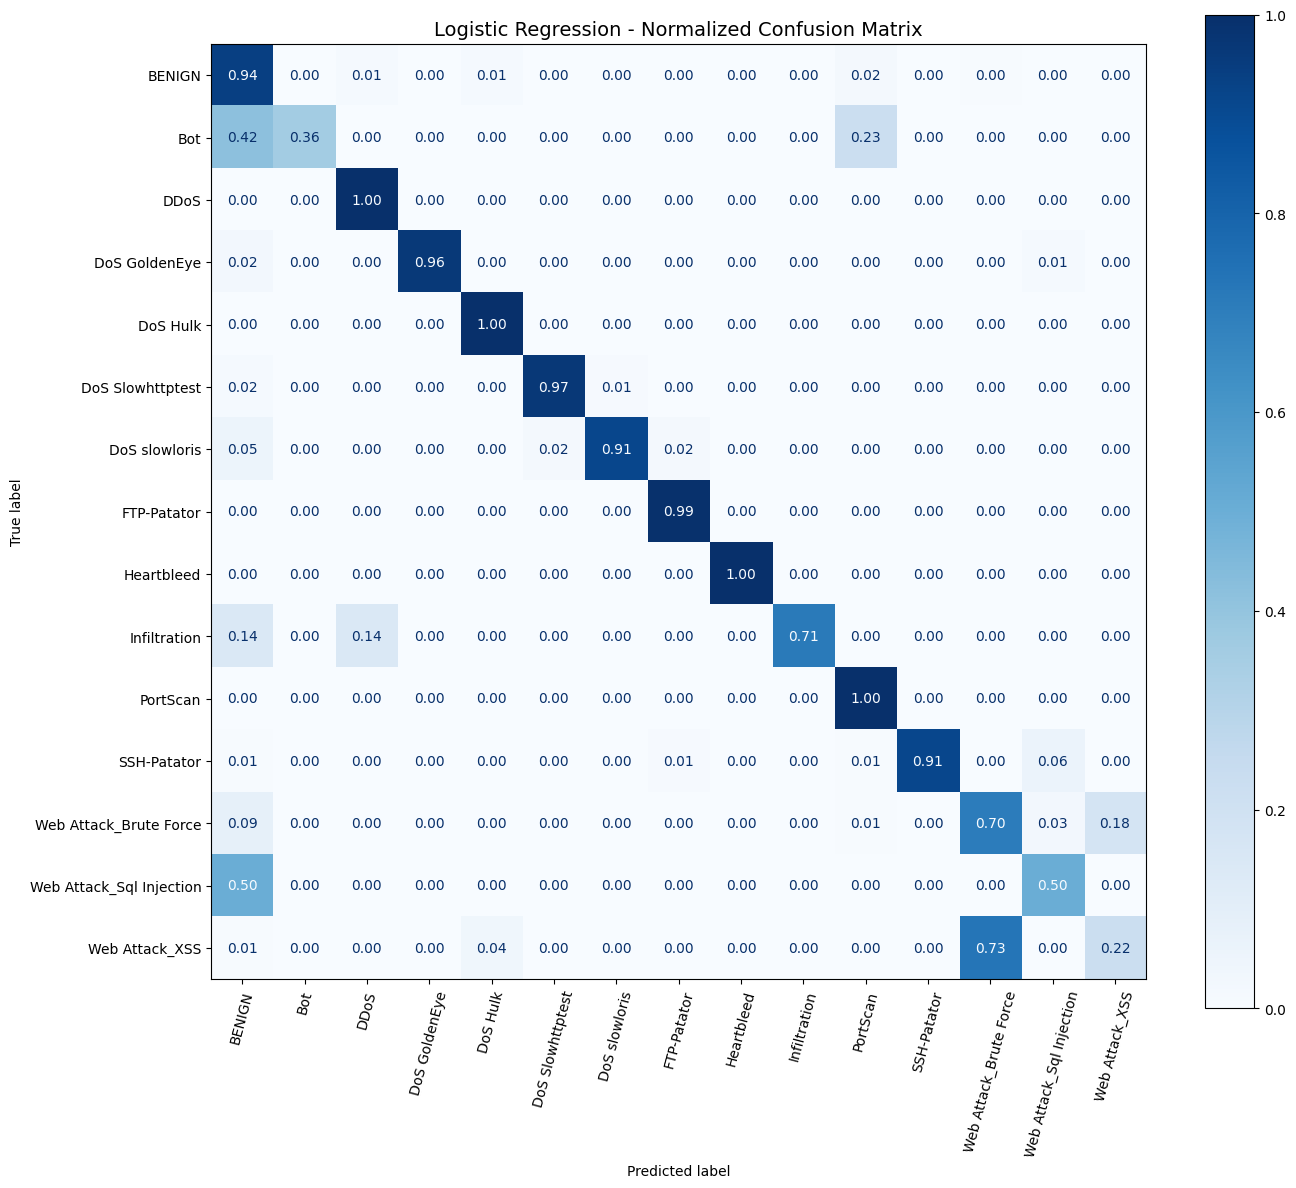

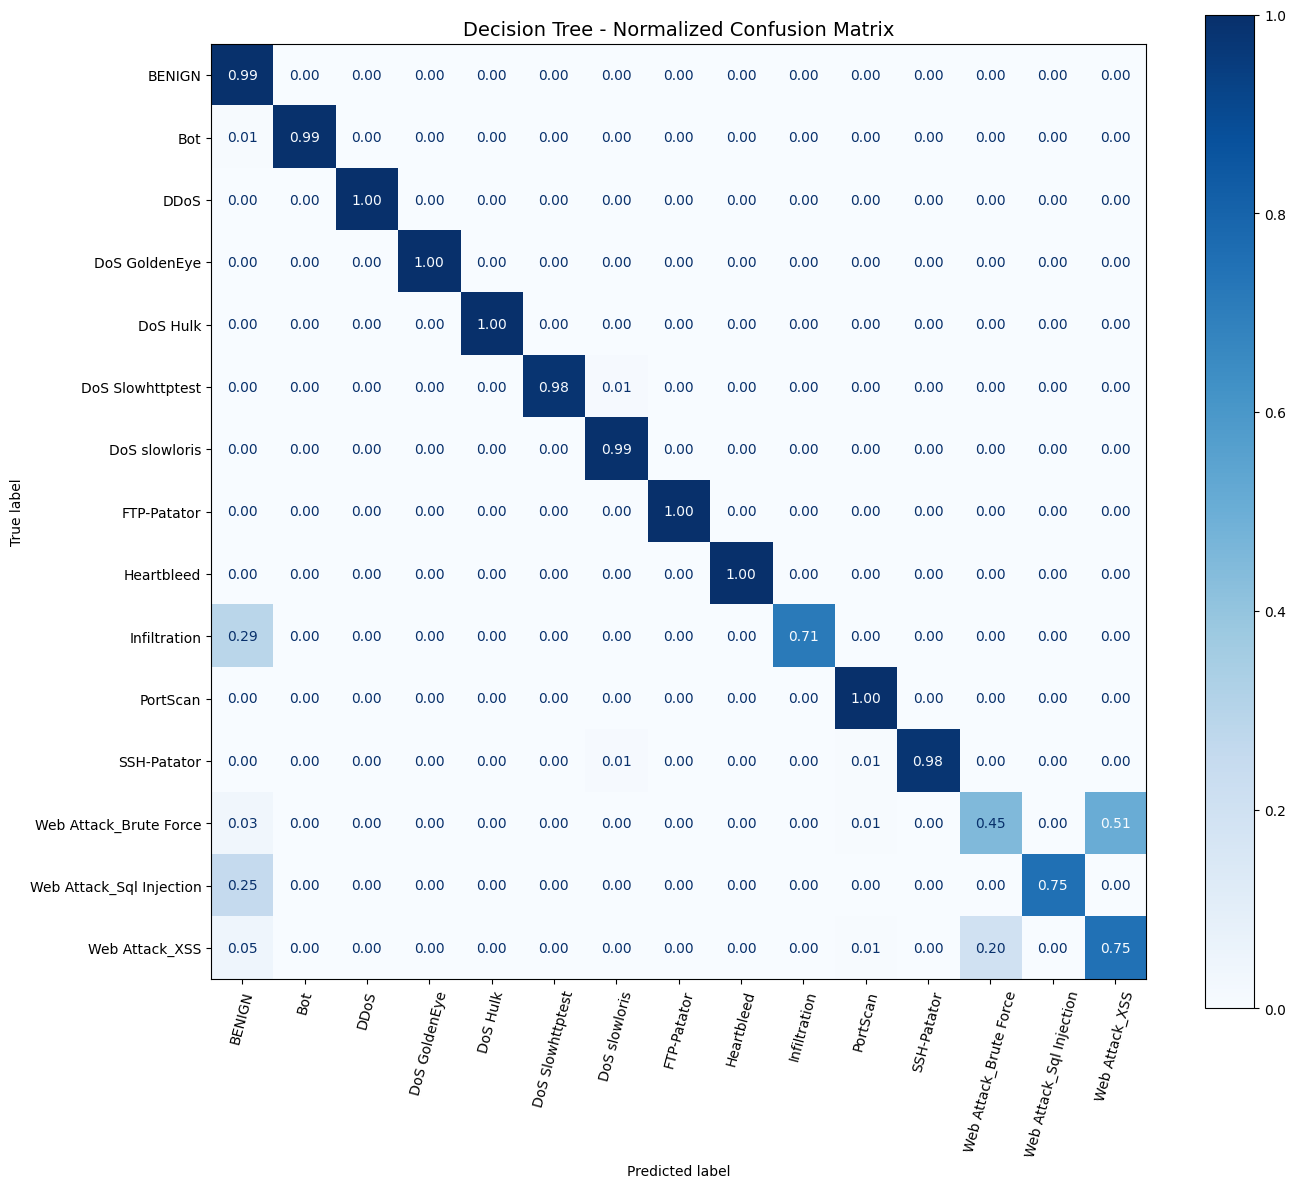

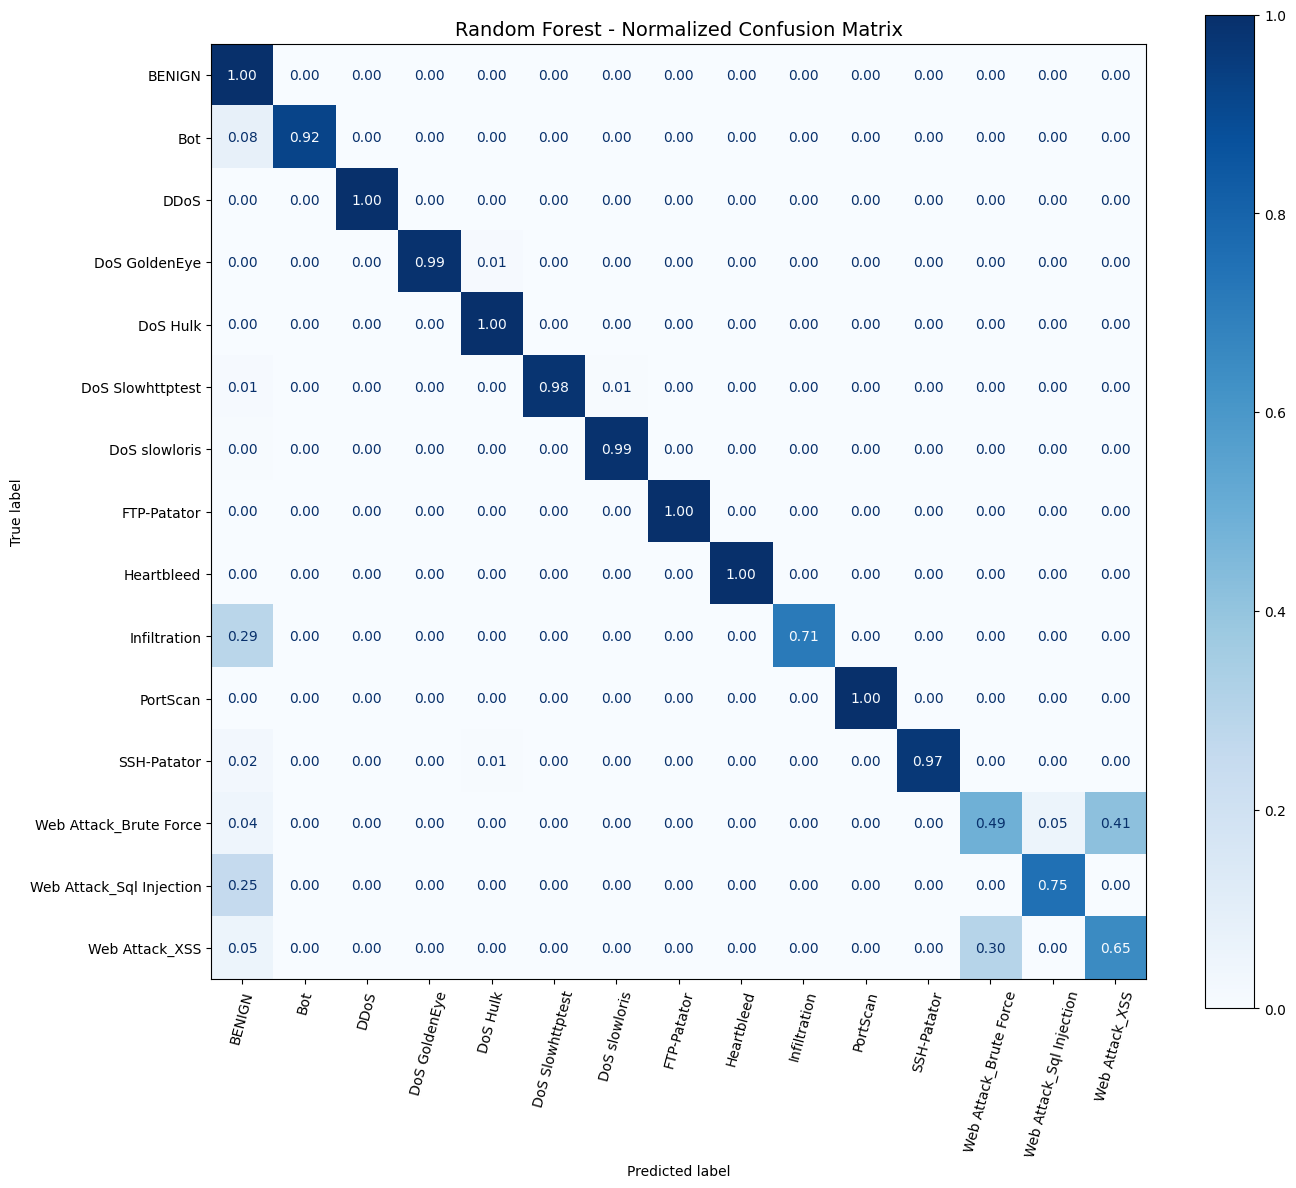

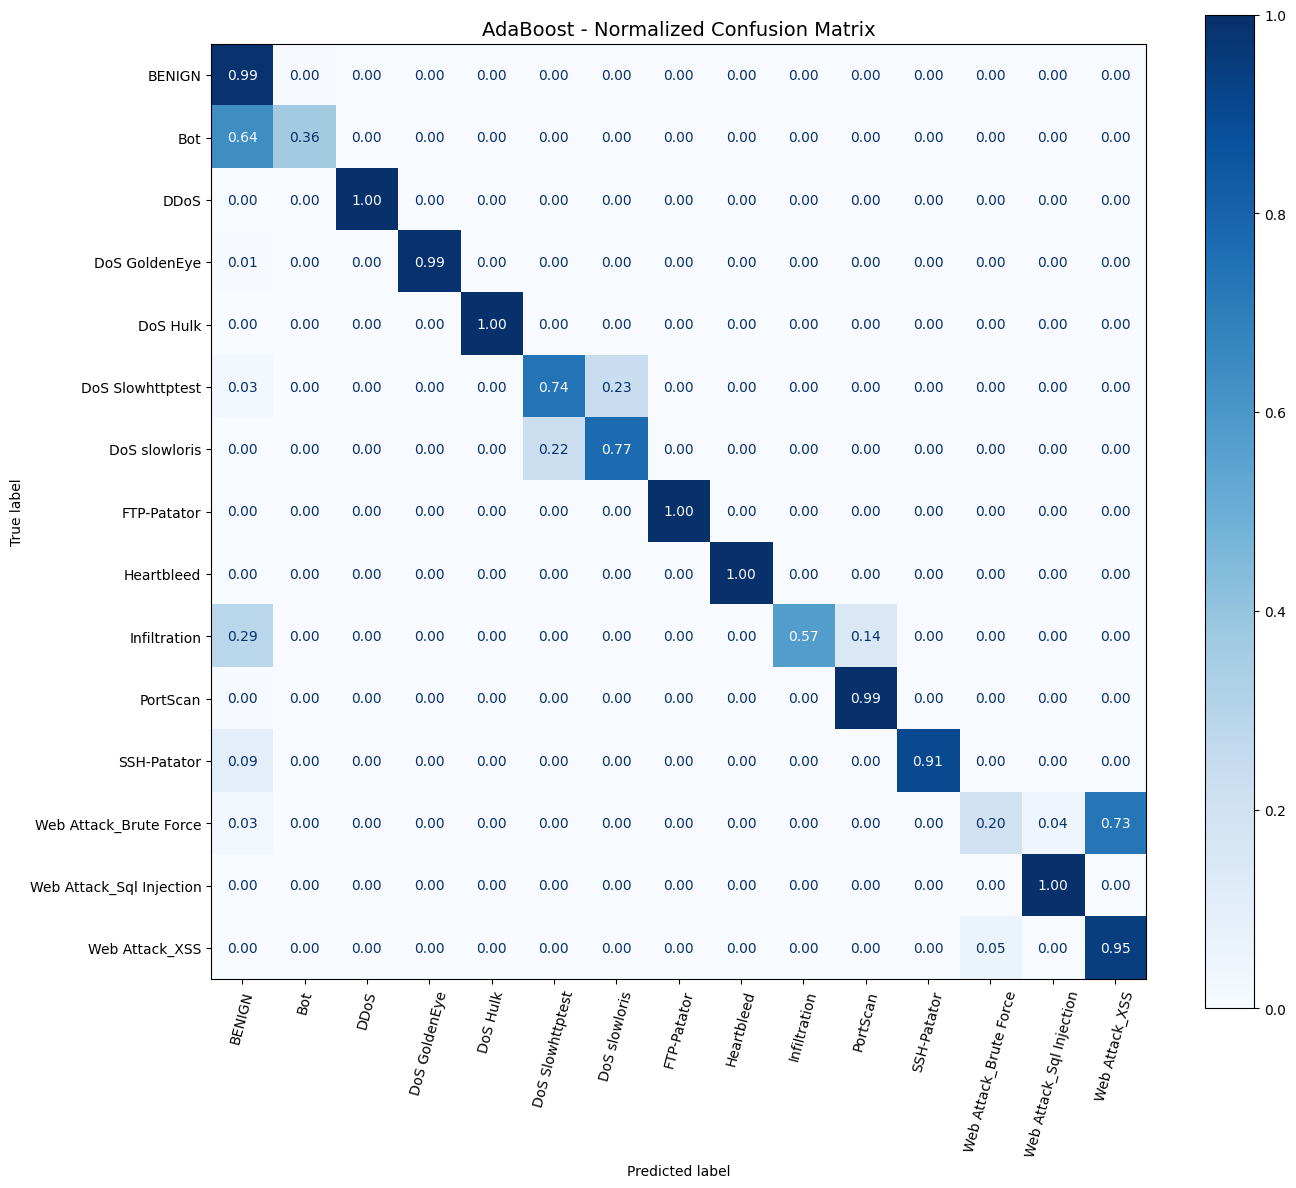

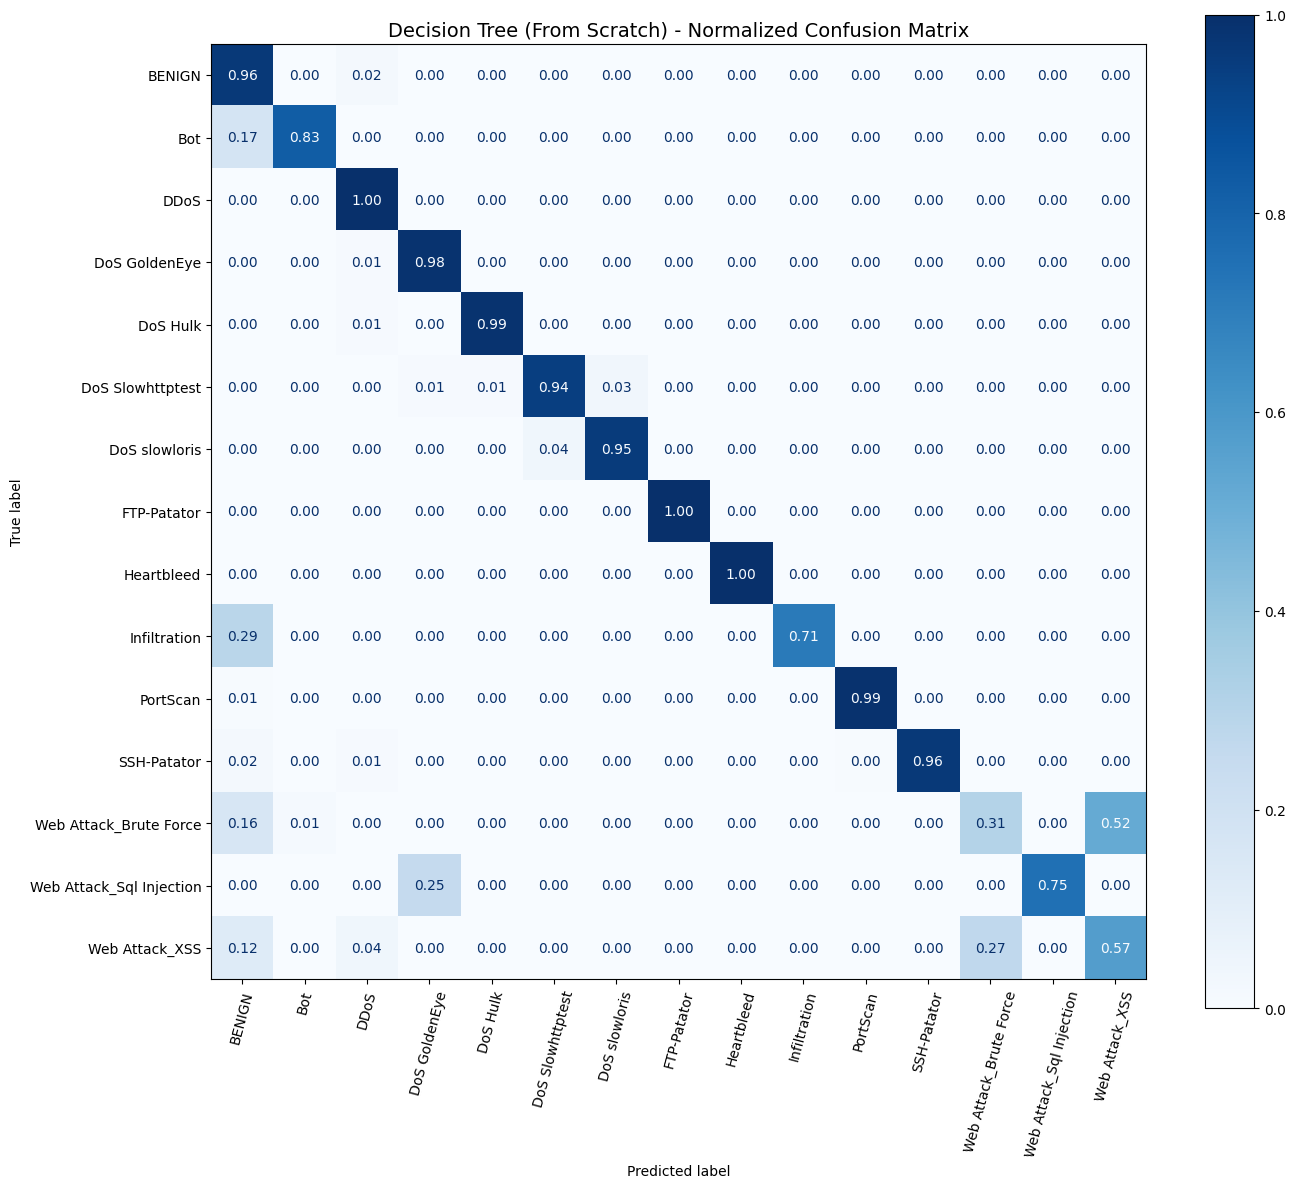

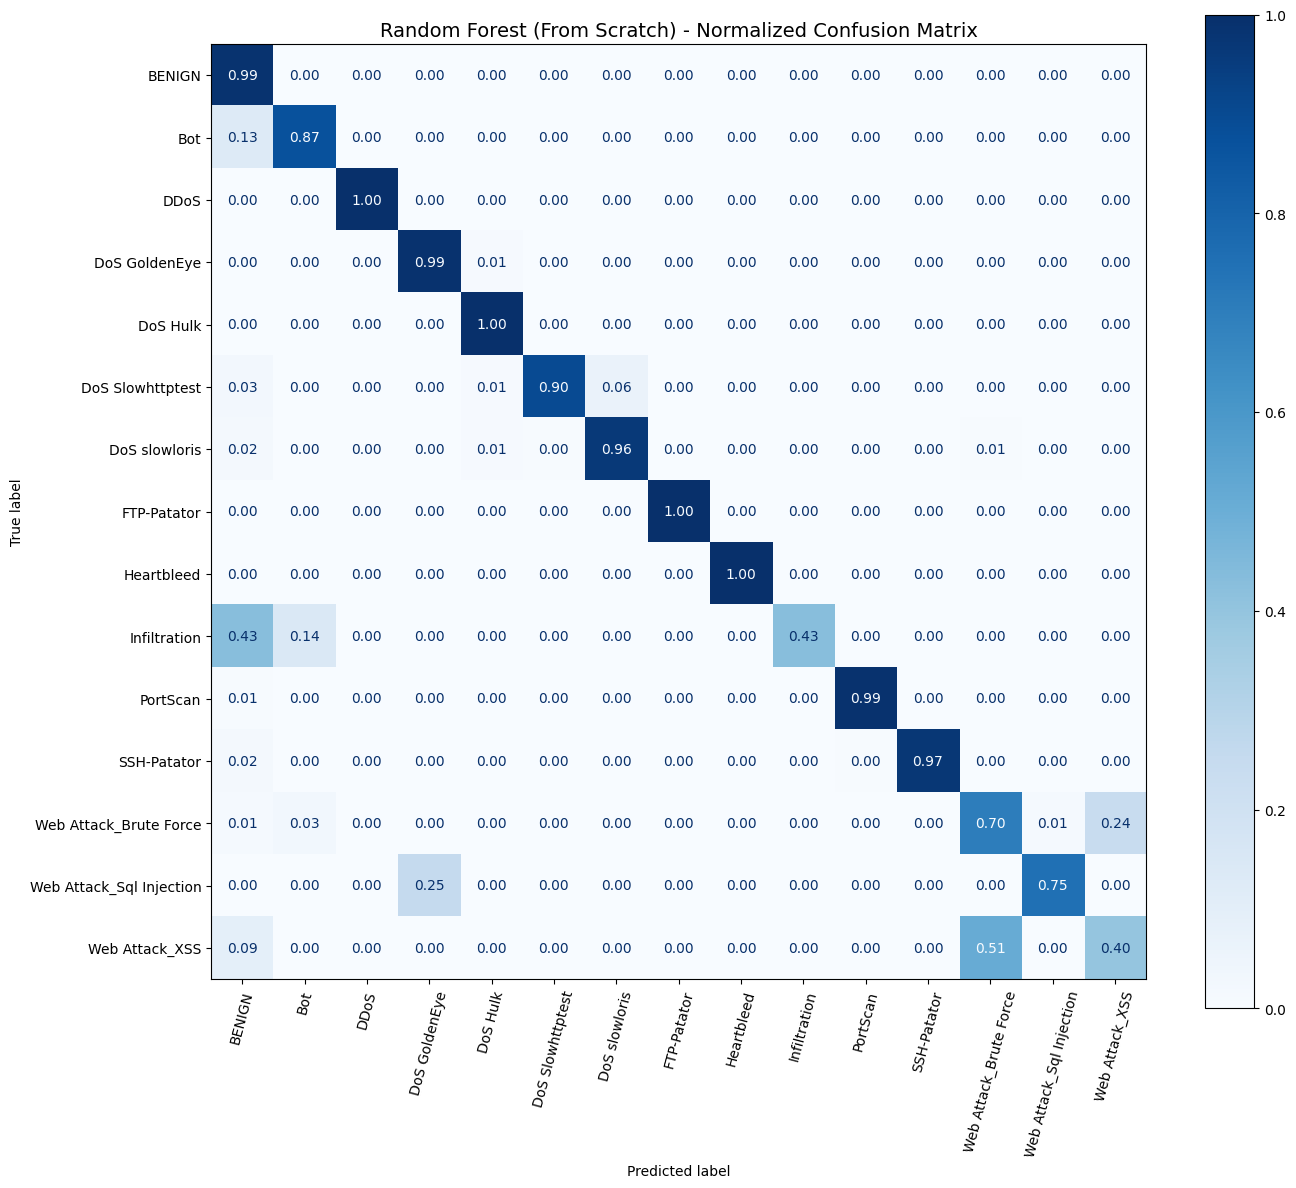

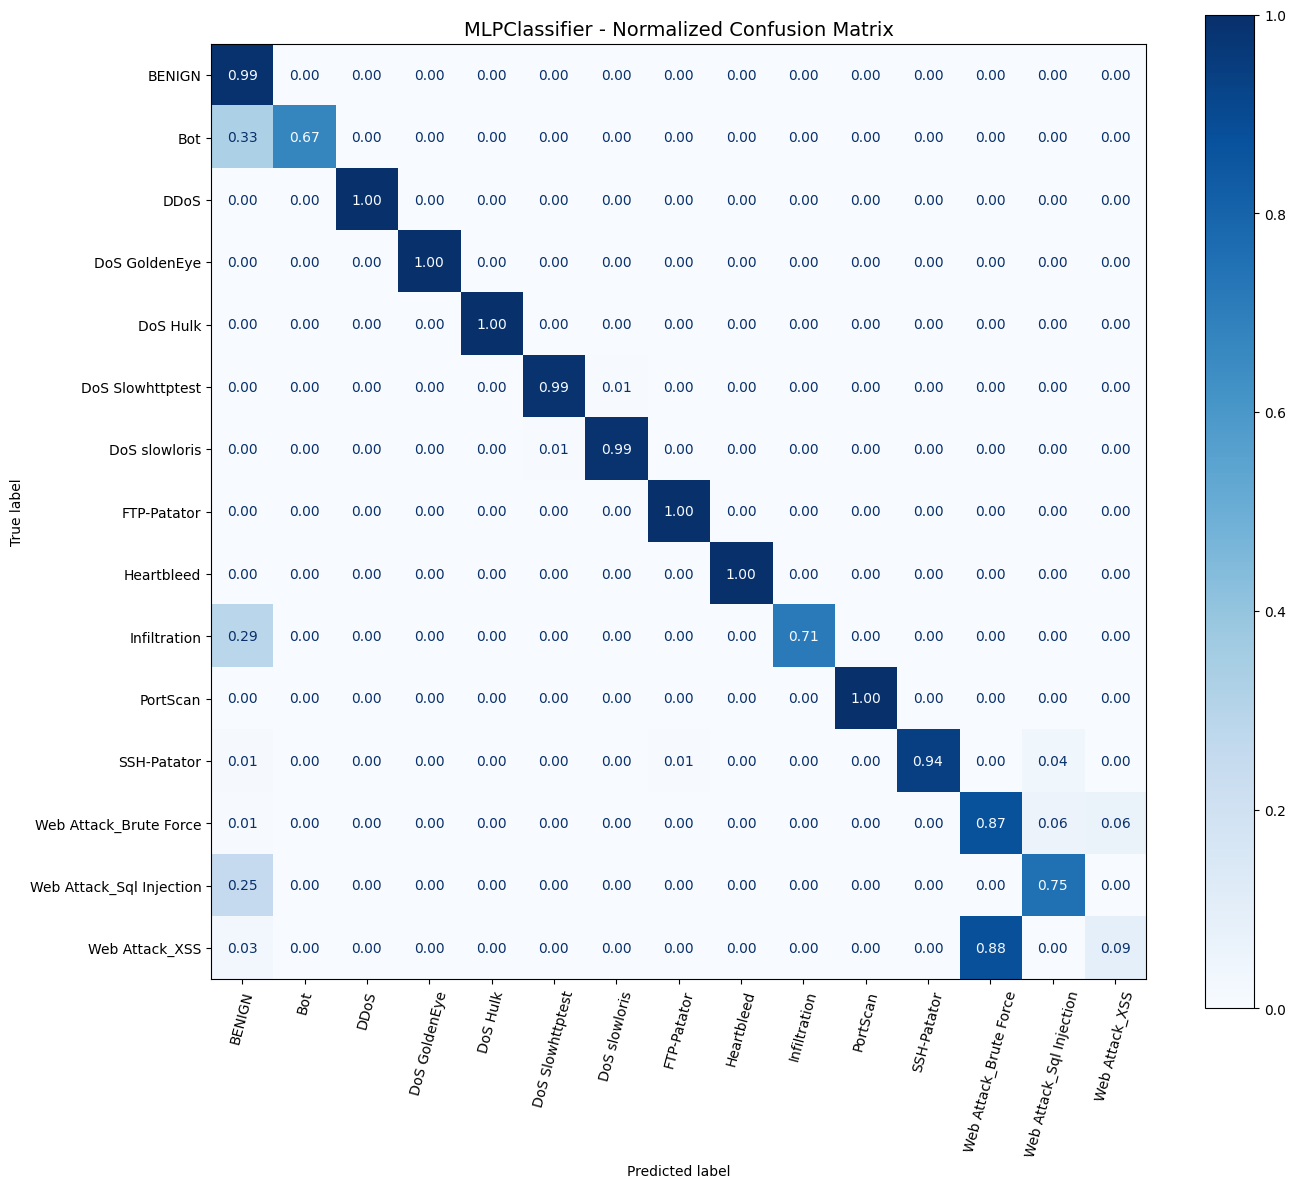

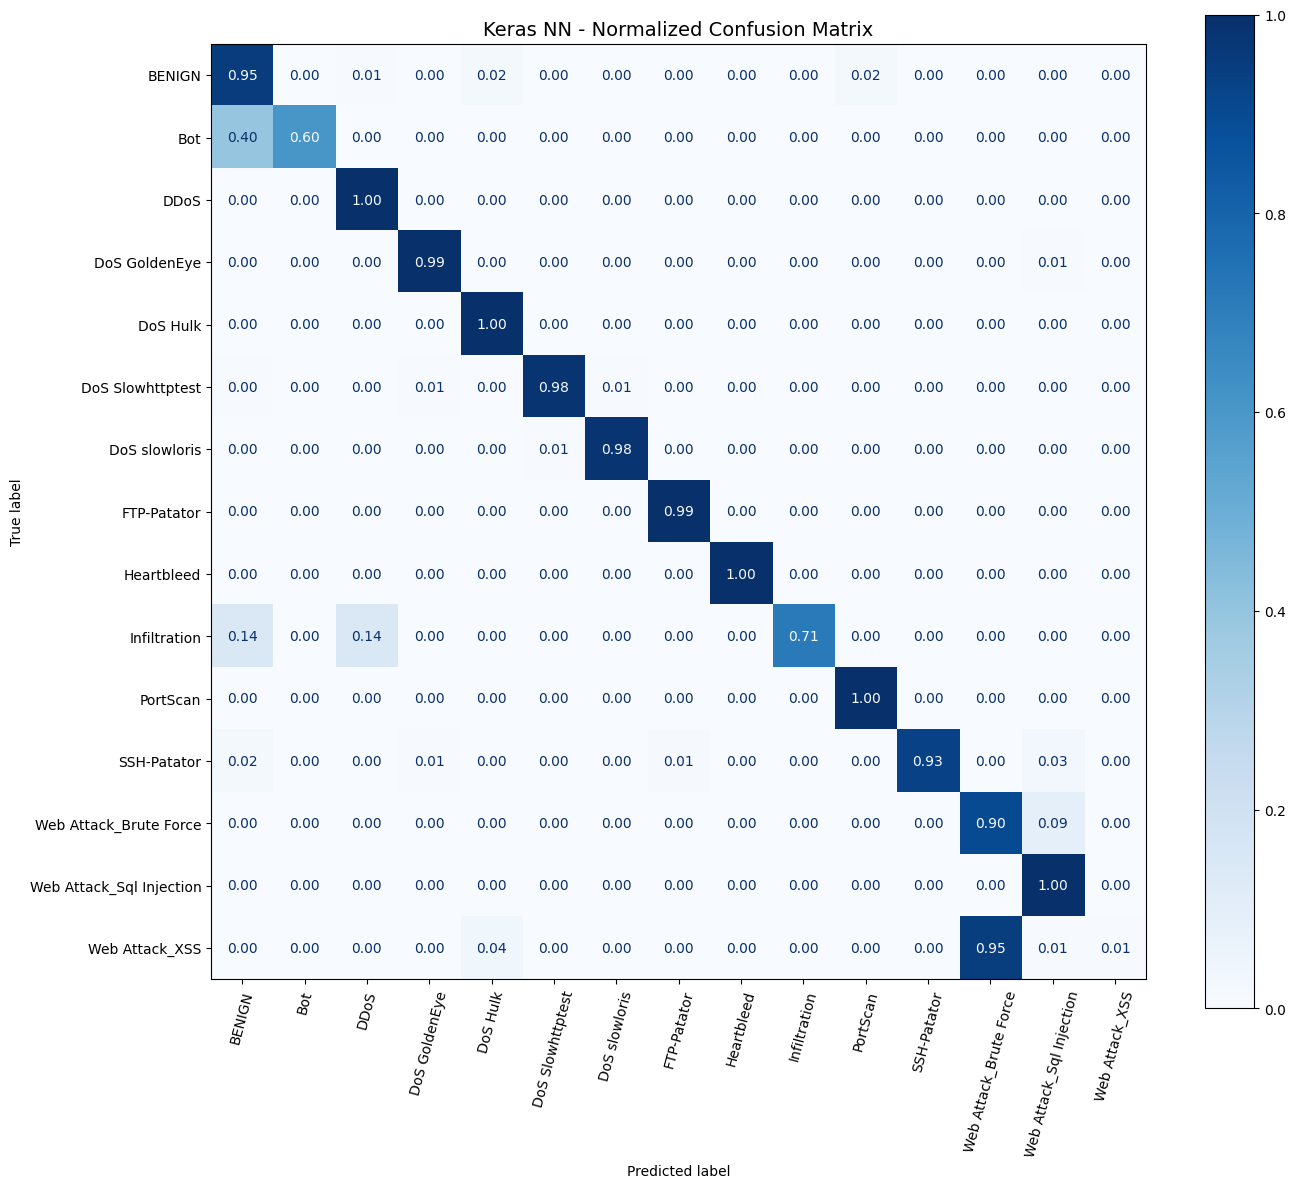

In [ ]:
# Logistic Regression
plot_confusion_matrix(y_test, y_pred_lr, le.classes_, "Logistic Regression - Normalized Confusion Matrix")

# Decision Tree
plot_confusion_matrix(y_test, y_pred_dt, le.classes_, "Decision Tree - Normalized Confusion Matrix")

# Random Forest
plot_confusion_matrix(y_test, y_pred_rf, le.classes_, "Random Forest - Normalized Confusion Matrix")

# AdaBoost
plot_confusion_matrix(y_test, y_pred_ada, le.classes_, "AdaBoost - Normalized Confusion Matrix")

# From-scratch Decision Tree
plot_confusion_matrix(y_test_np, y_pred_dt_scr, le.classes_, "Decision Tree (From Scratch) - Normalized Confusion Matrix")

# From-scratch Random Forest
plot_confusion_matrix(y_test_np, y_pred_rf_scr, le.classes_, "Random Forest (From Scratch) - Normalized Confusion Matrix")

# MLPClassifier
plot_confusion_matrix(y_test, y_pred_mlp, le.classes_, "MLPClassifier - Normalized Confusion Matrix")

# Keras NN
plot_confusion_matrix(y_test, y_pred_nn, le.classes_, "Keras NN - Normalized Confusion Matrix")


## For PCA (COMPARISON)

In [ ]:
# --- PCA for Modeling (fit only on training data) ---
scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train_res)
X_test_scaled = scaler_model.transform(X_test)

pca_model = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components (95% variance): {X_train_pca.shape[1]}")

Original features: 64
PCA components (95% variance): 23


In [ ]:
import time

pca_results = {}

# --- Logistic Regression + PCA ---
if len(y_train) > sklearn_sample_size:
    sub_idx = np.random.RandomState(42).choice(len(y_train_res), sklearn_sample_size, replace=False)
    X_train_pca_sk = X_train_pca[sub_idx]
    y_train_pca_sk = y_train.to_numpy()[sub_idx]
else:
    X_train_pca_sk = X_train_pca
    y_train_pca_sk = y_train.to_numpy()

t0 = time.time()
lr_pca = LogisticRegression(max_iter=500, random_state=42, n_jobs=-1)
lr_pca.fit(X_train_pca_sk, y_train_pca_sk)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
pca_results['Logistic Regression + PCA'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_pca),
    'Time (s)': time.time() - t0
}
print(f"LR + PCA done in {pca_results['Logistic Regression + PCA']['Time (s)']:.1f}s")

# --- Decision Tree + PCA ---
t0 = time.time()
dt_pca = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
dt_pca.fit(X_train_pca, y_train_res)
y_pred_dt_pca = dt_pca.predict(X_test_pca)
pca_results['Decision Tree + PCA'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt_pca),
    'Time (s)': time.time() - t0
}
print(f"DT + PCA done in {pca_results['Decision Tree + PCA']['Time (s)']:.1f}s")

# --- Random Forest + PCA ---
t0 = time.time()
rf_pca = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1, verbose=1)
rf_pca.fit(X_train_pca_sk, y_train_pca_sk)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

pca_results['Random Forest + PCA'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf_pca),
    'Time (s)': time.time() - t0
}
print(f"RF + PCA done in {pca_results['Random Forest + PCA']['Time (s)']:.1f}s")

# --- AdaBoost + PCA ---
t0 = time.time()
ada_pca = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)
ada_pca.fit(X_train_pca_sk, y_train_pca_sk)
y_pred_ada_pca = ada_pca.predict(X_test_pca)
pca_results['AdaBoost + PCA'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ada_pca),
    'Time (s)': time.time() - t0
}
print(f"AdaBoost + PCA done in {pca_results['AdaBoost + PCA']['Time (s)']:.1f}s")

LR + PCA done in 30.7s
DT + PCA done in 17.6s


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  1.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.6s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.8s finished


RF + PCA done in 68.3s
AdaBoost + PCA done in 255.3s


In [ ]:
# Combine into one comparison DataFrame
comparison_data = {
    'Model': [
        'Logistic Regression (no PCA)',
        'Logistic Regression + PCA',
        'Decision Tree (no PCA)',
        'Decision Tree + PCA',
        'Random Forest (no PCA)',
        'Random Forest + PCA',
        'AdaBoost (no PCA)',
        'AdaBoost + PCA',
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        pca_results['Logistic Regression + PCA']['Accuracy'],
        accuracy_score(y_test, y_pred_dt),
        pca_results['Decision Tree + PCA']['Accuracy'],
        accuracy_score(y_test, y_pred_rf),
        pca_results['Random Forest + PCA']['Accuracy'],
        accuracy_score(y_test, y_pred_ada),
        pca_results['AdaBoost + PCA']['Accuracy'],
    ],
    'Num Features': [
        X_train.shape[1], X_train_pca.shape[1],
        X_train.shape[1], X_train_pca.shape[1],
        X_train.shape[1], X_train_pca.shape[1],
        X_train.shape[1], X_train_pca.shape[1],
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Accuracy'] = comparison_df['Accuracy'].round(4)
comparison_df = comparison_df.sort_values('Model').reset_index(drop=True)

print("\n=== PCA vs No-PCA Comparison ===")
print(comparison_df)


=== PCA vs No-PCA Comparison ===
                          Model  Accuracy  Num Features
0             AdaBoost (no PCA)    0.9868            64
1                AdaBoost + PCA    0.8289            23
2        Decision Tree (no PCA)    0.9939            64
3           Decision Tree + PCA    0.9785            23
4  Logistic Regression (no PCA)    0.9469            64
5     Logistic Regression + PCA    0.8296            23
6        Random Forest (no PCA)    0.9973            64
7           Random Forest + PCA    0.8296            23


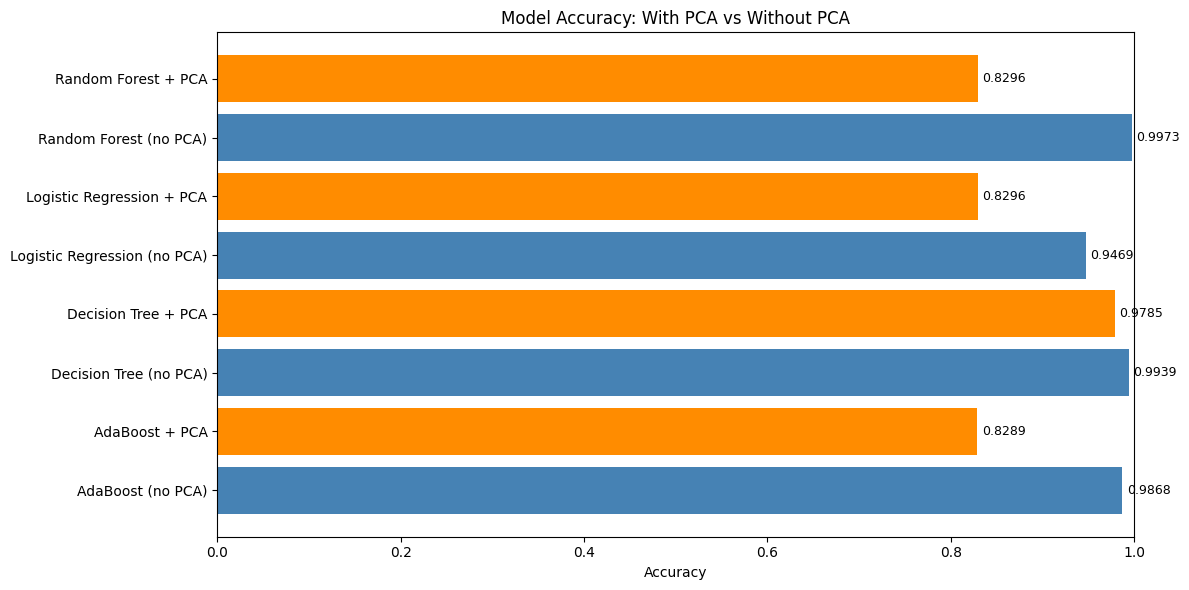

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['steelblue' if 'no PCA' in m else 'darkorange' for m in comparison_df['Model']]
plt.barh(comparison_df['Model'], comparison_df['Accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('Model Accuracy: With PCA vs Without PCA')
plt.xlim(0, 1)
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(v + 0.005, i, f"{v:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

Results Summary

In [ ]:
# Base (non-PCA) results table, built from the models trained above
results = pd.DataFrame({
    'Model': [
        'Decision Tree (from scratch)',
        'Random Forest (from scratch)',
        'Logistic Regression (no PCA)',
        'Decision Tree (no PCA)',
        'Random Forest (no PCA)',
        'AdaBoost (no PCA)',
        'MLPClassifier (Neural Net)',
        'Keras Sequential (Neural Net)',
    ],
    'Accuracy': [
        accuracy_dt_scr,
        accuracy_rf_scr,
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_nn),
    ]
})
results['Accuracy'] = results['Accuracy'].round(4)
print(results.sort_values('Accuracy', ascending=False))

                           Model  Accuracy
4         Random Forest (no PCA)    0.9973
3         Decision Tree (no PCA)    0.9939
6     MLPClassifier (Neural Net)    0.9922
1   Random Forest (from scratch)    0.9883
5              AdaBoost (no PCA)    0.9868
0   Decision Tree (from scratch)    0.9679
7  Keras Sequential (Neural Net)    0.9589
2   Logistic Regression (no PCA)    0.9469


In [ ]:
final_results = pd.concat([results, comparison_df[['Model', 'Accuracy']]], ignore_index=True)
final_results = final_results.drop_duplicates(subset='Model').reset_index(drop=True)

print("\n=========== FINAL COMBINED RESULTS ===========")
print(final_results.sort_values('Accuracy', ascending=False))


=========== FINAL COMBINED RESULTS ===========
                            Model  Accuracy
4          Random Forest (no PCA)    0.9973
3          Decision Tree (no PCA)    0.9939
6      MLPClassifier (Neural Net)    0.9922
1    Random Forest (from scratch)    0.9883
5               AdaBoost (no PCA)    0.9868
9             Decision Tree + PCA    0.9785
0    Decision Tree (from scratch)    0.9679
7   Keras Sequential (Neural Net)    0.9589
2    Logistic Regression (no PCA)    0.9469
10      Logistic Regression + PCA    0.8296
11            Random Forest + PCA    0.8296
8                  AdaBoost + PCA    0.8289


Conclusion:

This project applied multiple machine learning approaches to detect and classify network intrusions using the CICIDS2017 dataset. This is a multiclass classification problem and heavily imbalanced.

This project demonstrates that both classical machine learning models and from scratch implementations can effectively detect network intrusions.It shows that tree based ensemble methods offers the strongest balance of accuracy and robustness to class imbalance. The comparative approach sklearn versus from scratch, with versus without PCA provided a more complete picture of trade-offs between accuracy, interpretability, and computational efficiency than any single model evaluation could offer alone.

Limitations:

Overall accuracy, however, told only part of the story. Because BENIGN traffic vastly outnumbers any individual attack class, high accuracy could be achieved even by models that performed poorly on rare attack types. The confusion matrices reinforced this finding at a finer level of detail: most models achieved strong diagonal performance for both BENIGN traffic and well-represented attack types